In [1]:
import matplotlib.pyplot as plt
import numpy as np

import time

import sys
import os

from datetime import datetime
import subprocess

os.environ['CUDA_VISIBLE_DEVICES']="1"


from keras.layers import Dense, Input, Dropout, BatchNormalization
from keras.models import Model, Sequential

from keras.regularizers import l2, l1, l1_l2

from sklearn.model_selection import train_test_split

import pickle


import tensorflow as tf




2025-02-10 11:36:07.444200: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-10 11:36:07.460483: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8463] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-10 11:36:07.465626: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import optree
import keras
print(optree.__version__)
print(keras.__version__)

0.13.0
3.4.1


In [3]:
print("\n\n")
print("  numpy version:  %s" % str(np.version.version) )
print("  tensorflow version:  %s" % str(tf.__version__))
print("\n\n")




  numpy version:  1.26.4
  tensorflow version:  2.17.0





In [4]:
from keras.layers import Activation

beta = 4

def custom_activation(x):
    return 0.5 * x * (1 + K.tanh( beta * 0.79788 * (x + 0.044715 * x * x * x)))

## Set model and resolution parameters

In [5]:



output_dir = 'bootstrap-ensemble-1d-1b'





ndim = 1

##-------------

train_mu = [ 0.0 ]



train_rho = [ [0.0] ]






train_sig = [ 1.0 ]


##-------------


true_mu = [ 0.2 ]






true_rho  = [ [0.0] ]



true_sig = [ 0.9 ]



#--- perfect
#resolution = [ 0.00001  ]

#--- good
#resolution = [ 0.25  ]

#--- nominal
resolution = [ 0.5  ]

#--- medium bad
#resolution = [ 0.75  ]

#--- poor
#resolution = [ 1.0  ]






train_cov = np.zeros( shape=(ndim,ndim) )
true_cov  = np.zeros( shape=(ndim,ndim) )

print("\n\n\n Train covariance:")

for i in range(ndim) :
    for j in range(ndim) :
        if j < i : continue
        if i == j :
            train_cov[i][j] = train_sig[i] * train_sig[j]
            print("  %2d, %2d : diagonal  %8.4f" % (i,j, train_cov[i][j]))
        else :
            k = ndim - j - 1
            train_cov[i][j] = train_sig[i] * train_sig[j] * train_rho[i][k]
            train_cov[j][i] = train_cov[i][j]
            print("  %2d, %2d :           %8.3f * %8.3f * %8.3f = %8.4f" % 
                  (i,j, train_sig[i], train_sig[j], train_rho[i][k], train_cov[i][j]))
            
            

print("\n\n\n True covariance:")  

for i in range(ndim) :
    for j in range(ndim) :
        if j < i : continue
        if i == j :
            true_cov[i][j] = true_sig[i] * true_sig[j]
            print("  %2d, %2d : diagonal  %8.4f" % (i,j, true_cov[i][j]))
        else :
            k = ndim - j - 1
            true_cov[i][j] = true_sig[i] * true_sig[j] * true_rho[i][k]
            true_cov[j][i] = true_cov[i][j]
            print("  %2d, %2d :           %8.3f * %8.3f * %8.3f = %8.4f" % 
                  (i,j, true_sig[i], true_sig[j], true_rho[i][k], true_cov[i][j]))
            
            
                

                
#-- about 10 seconds
#ngen_train = 10000
#ngen_true =   1000              

                
#-- about 62 seconds
#ngen_train = 100000
#ngen_true =    1000       


#-- about 37  (29 in of8a)  seconds
ngen_train = 100000
ngen_true =   10000

#-- about 47  (38 in of8a)  seconds
#ngen_train = 1000000
#ngen_true =   100000

#-- about 1   (56 seconds) minute
#ngen_train = 2000000
#ngen_true =   200000

#-- about 1:50  (1:48 in of8a)
#ngen_train = 4000000
#ngen_true =   400000

#-- about 5 min
#ngen_train = 10000000
#ngen_true =   1000000







of_niter = 5

#of_niter = 10

#of_niter = 4

#of_niter = 2

#of_niter = 1



#learning_rate_setval = 0.0005
#epochs_setval = 40

#learning_rate_setval = 0.0001
#epochs_setval = 10

#learning_rate_setval = 0.00002
#epochs_setval = 40

#learning_rate_setval = 0.0005
#epochs_setval = 10

#learning_rate_setval = 0.0010
#epochs_setval = 10

#learning_rate_setval = 0.0008
#epochs_setval = 10


#learning_rate_setval = 0.0005
#epochs_setval = 20





learning_rate_setval = 0.0005

#learning_rate_setval = 0.0001

#learning_rate_setval = 0.0010

#learning_rate_setval = 0.0020

#learning_rate_setval = 0.0050






#epochs_setval = 100

epochs_setval = 50

#epochs_setval = 1

#epochs_setval = 5

#epochs_setval = 20




dropout_setval = 0.0

#dropout_setval = 0.02

#dropout_setval = 0.10

#dropout_setval = 0.20

#dropout_setval = 0.30

#dropout_setval = 0.40





#patience_setval = 5

#patience_setval = 25

#patience_setval = 200

patience_setval = -1



batch_size_setval = int( ngen_true )

#batch_size_setval = int( ngen_true/10 )

#batch_size_setval = int( ngen_true/100 )

#batch_size_setval = 512


use_batch_norm = False






units_per_layer = 50

#units_per_layer = 10

#units_per_layer = 25

#units_per_layer = 80

#units_per_layer = 40

#units_per_layer = 100

#units_per_layer = 200

#units_per_layer = 400

#units_per_layer = 800

#units_per_layer = 1000

#units_per_layer = 2000

#units_per_layer = 4000

#units_per_layer = 20000





number_of_layers = 3

#number_of_layers = 2

#number_of_layers = 1





#l1reg_kernel_setval = 0.000001

#l1reg_kernel_setval = 0.00001

#l1reg_kernel_setval = 0.000005

l1reg_kernel_setval = 0.0

#l1reg_kernel_setval = 0.0001

#l1reg_kernel_setval = 0.001




#l2reg_kernel_setval = 0.000005

l2reg_kernel_setval = 0.0

#l2reg_kernel_setval = 0.001




#l1reg_activation_setval = 0.000005

#l1reg_activation_setval = 0.0000005

#l1reg_activation_setval = 0.00000005

l1reg_activation_setval = 0.0



l2reg_activation_setval = 0.0

#l2reg_activation_setval = 0.0000005

#l2reg_activation_setval = 0.00000005

#l2reg_activation_setval = 0.000000005




#l1reg_bias_setval = 0.01

#l1reg_bias_setval = 0.00001

l1reg_bias_setval = 0.0


l2reg_bias_setval = 0.0

#l2reg_bias_setval = 0.00001




#activation_setval = 'softplus'

activation_setval = 'relu'

#activation_setval = 'gelu'

#activation_setval = custom_activation




do_bootstrap = False

n_boot_samples = 100

use_poisson_fluctuations_around_ngen_true = True




n_models_to_ensemble = 5



random_seed = 1


save_step2_model = True





 Train covariance:
   0,  0 : diagonal    1.0000



 True covariance:
   0,  0 : diagonal    0.8100


In [6]:
try:
    os.mkdir( output_dir )
except:
    print('\n\n Output directory already exists:  %s' % output_dir)
    #print('\n\n HALTING EXECUTION\n\n')
    #sys.exit()

In [7]:
print("\n\n")
print("Train covariance determinant:  %f" % np.linalg.det( train_cov ) )
print("True covariance determinant:   %f" % np.linalg.det( true_cov ) )
print("\n\n")




Train covariance determinant:  1.000000
True covariance determinant:   0.810000





In [8]:
train_cov_inv = np.linalg.inv( train_cov )

In [9]:
train_cov_inv_test = np.matmul( train_cov, train_cov_inv )

In [10]:
print("\n\n")
print(" Train covariance")
print( train_cov )
print("\n Train covariance inverse")
print( train_cov_inv )
print("\n Train covariance inverse test")
print(train_cov_inv_test)
print("\n\n")




 Train covariance
[[1.]]

 Train covariance inverse
[[1.]]

 Train covariance inverse test
[[1.]]





In [11]:
true_cov_inv = np.linalg.inv( true_cov )

In [12]:
true_cov_inv_test = np.matmul( true_cov, true_cov_inv )

In [13]:
print("\n\n")
print(" True covariance")
print( true_cov )
print("\n True covariance inverse")
print( true_cov_inv )
print("\n True covariance inverse test")
print(true_cov_inv_test)
print("\n\n")




 True covariance
[[0.81]]

 True covariance inverse
[[1.2345679]]

 True covariance inverse test
[[1.]]





## Generate samples, save events and config

In [14]:

np.random.seed( random_seed )
keras.utils.set_random_seed( random_seed )



train_pts = np.random.multivariate_normal(train_mu, train_cov, size=ngen_train)
true_pts = np.random.multivariate_normal(true_mu, true_cov, size=ngen_true)

train_det_pts = np.random.normal( train_pts, resolution )

true_det_pts = np.random.normal( true_pts, resolution )


true_pts10x = np.random.multivariate_normal(true_mu, true_cov, size=ngen_true*40)
true_det_pts10x = np.random.normal( true_pts10x, resolution )
true_pts10x_weights = np.ones( ngen_true*40 )
true_pts10x_weights = (1./40.) * true_pts10x_weights


In [15]:
with open( '%s/train-and-true-samples.npy' % output_dir, 'wb') as f :
    np.save(f, train_pts)
    np.save(f, train_det_pts)
    np.save(f, true_pts)
    np.save(f, true_det_pts)

In [16]:
with open( '%s/config-pars.npy' % output_dir , 'wb' ) as f :
    np.save( f, train_mu )
    np.save( f, train_rho )
    np.save( f, train_sig )
    np.save( f, true_mu )
    np.save( f, true_rho )
    np.save( f, true_sig )
    np.save( f, resolution )
    np.save( f, train_cov )
    np.save( f, true_cov )

In [17]:
with open('%s/config-pars.pkl' % output_dir, 'wb') as f :
    pickle.dump( train_mu, f)
    pickle.dump( train_rho, f)
    pickle.dump( train_sig, f)
    pickle.dump( true_mu,f)
    pickle.dump( true_rho,f)
    pickle.dump( true_sig,f)
    pickle.dump( resolution,f)
    pickle.dump( train_cov,f)
    pickle.dump( true_cov,f)

In [18]:
config_filename = '%s/config.txt' % output_dir

config_file = open( config_filename, 'w' )

config_file.write('%s\n\n' % datetime.now() )
config_file.write('ngen_train %d\n' % ngen_train )
config_file.write('ngen_true  %d\n' % ngen_true )
config_file.write('of_niter   %d\n' % of_niter )
config_file.write('ndim       %d\n' % ndim )
config_file.write('learning_rate_setval  %f\n' % learning_rate_setval )
config_file.write('epochs_setval  %d\n' % epochs_setval )
config_file.write('batch_size_setval  %d\n' % batch_size_setval )
config_file.write( 'random_seed:  %d\n' % random_seed  )
config_file.write('l1reg_kernel_setval  %s\n' % l1reg_kernel_setval )
config_file.write('l2reg_kernel_setval  %s\n' % l2reg_kernel_setval )
config_file.write('l1reg_activation_setval  %s\n' % l1reg_activation_setval )
config_file.write('l2reg_activation_setval  %s\n' % l2reg_activation_setval )
config_file.write('l1reg_bias_setval  %s\n' % l1reg_bias_setval )
config_file.write('l2reg_bias_setval  %s\n' % l2reg_bias_setval )
config_file.write('activation_setval  %s\n' % activation_setval )
config_file.write('beta  %s\n' % beta )
config_file.write('n_models_to_ensemble %d\n' % n_models_to_ensemble )



config_file.write('\n\n')
config_file.write('train_mu : %s\n' % str(train_mu))
config_file.write('train_rho : %s\n' % str(train_rho))
config_file.write('train_sig : %s\n' % str(train_sig))
config_file.write('train_cov : %s\n' % str(train_cov))
config_file.write('\n\n')
config_file.write('true_mu : %s\n' % str(true_mu))
config_file.write('true_rho : %s\n' % str(true_rho))
config_file.write('true_sig : %s\n' % str(true_sig))
config_file.write('true_cov : %s\n' % str(true_cov))
config_file.write('\n\n')
config_file.write('resolution : %s\n' % str(resolution) )
config_file.close()

print('\n\n  Config file contents : %s\n' % config_filename )
print( subprocess.getoutput('cat %s' % config_filename ))
print('\n\n')





  Config file contents : bootstrap-ensemble-1d-1b/config.txt

2025-02-10 11:36:09.299871

ngen_train 100000
ngen_true  10000
of_niter   5
ndim       1
learning_rate_setval  0.000500
epochs_setval  50
batch_size_setval  10000
random_seed:  1
l1reg_kernel_setval  0.0
l2reg_kernel_setval  0.0
l1reg_activation_setval  0.0
l2reg_activation_setval  0.0
l1reg_bias_setval  0.0
l2reg_bias_setval  0.0
activation_setval  relu
beta  4
n_models_to_ensemble 5


train_mu : [0.0]
train_rho : [[0.0]]
train_sig : [1.0]
train_cov : [[1.]]


true_mu : [0.2]
true_rho : [[0.0]]
true_sig : [0.9]
true_cov : [[0.81]]


resolution : [0.5]





## Plots to visualize these parameter choices

<function matplotlib.pyplot.show(close=None, block=None)>

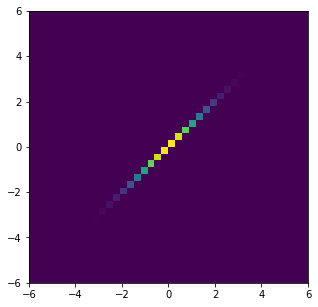

In [19]:
fig,ax = plt.subplots( ndim, ndim, figsize=(ndim*5, ndim*5))

hmin=-6
hmax=6
hbins=40

for i in range(ndim) :
    for j in range(ndim) :
        if j < i : continue
        if ndim > 1 :
            thisax = ax[i][j]
        else :
            thisax = ax
            
        thisax.hist2d( train_pts[:,i], train_pts[:,j], bins=[hbins,hbins], range=([hmin,hmax],[hmin,hmax]))



plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

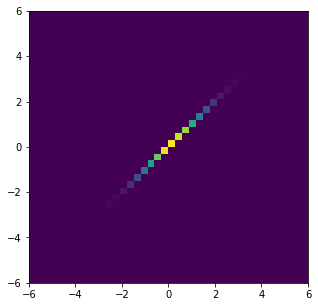

In [20]:
fig,ax = plt.subplots( ndim, ndim, figsize=(ndim*5, ndim*5))

hmin=-6
hmax=6
hbins=40

for i in range(ndim) :
    for j in range(ndim) :
        if j < i : continue
        if ndim > 1 :
            thisax = ax[i][j]
        else :
            thisax = ax
        thisax.hist2d( true_pts[:,i], true_pts[:,j], bins=[hbins,hbins], range=([hmin,hmax],[hmin,hmax]))



plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

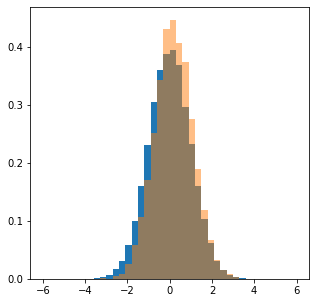

In [21]:
fig,ax = plt.subplots( 1, ndim, figsize=(ndim*5,5))

hmin=-6
hmax=6
hbins=40


for i in range(ndim) :
        k = i*3 + j
        if ndim > 1 :
            thisax = ax[i]
        else :
            thisax = ax
        thisax.hist( train_pts[:,i],bins=hbins, range=[hmin,hmax], density=True )
        thisax.hist( true_pts[:,i],bins=hbins, range=[hmin,hmax], density=True, alpha=0.5 )
    
plt.show

### Calculate true weights analytically and compare with unfolding output weights.

In [22]:
train_pts_minus_train_mu = train_pts - train_mu
print(train_pts_minus_train_mu)

[[ 1.62434536]
 [-0.61175641]
 [-0.52817175]
 ...
 [ 0.08122531]
 [ 0.34404618]
 [-0.74755625]]


In [23]:
train_pts_minus_true_mu = train_pts - true_mu
print(train_pts_minus_true_mu)

[[ 1.42434536]
 [-0.81175641]
 [-0.72817175]
 ...
 [-0.11877469]
 [ 0.14404618]
 [-0.94755625]]


In [24]:
true_cov_inv_times_v = np.tensordot( true_cov_inv, train_pts_minus_true_mu.T, axes=(1,0) )

In [25]:
v_times_true_cov_inv_times_v =  np.sum( train_pts_minus_true_mu.T * true_cov_inv_times_v, axis=0)

In [26]:
train_cov_inv_times_v = np.tensordot( train_cov_inv, train_pts_minus_train_mu.T, axes=(1,0) )

In [27]:
v_times_train_cov_inv_times_v =  np.sum( train_pts_minus_train_mu.T * train_cov_inv_times_v, axis=0)

In [28]:
exp_v_times_train_cov_inv_times_v = np.exp( -0.5 * v_times_train_cov_inv_times_v )
exp_v_times_true_cov_inv_times_v  = np.exp( -0.5 * v_times_true_cov_inv_times_v  )

In [29]:
true_cov_det = np.linalg.det( true_cov )
train_cov_det = np.linalg.det( train_cov )

In [30]:
norm2_true = np.power( 3.14159265, ndim) * true_cov_det
print("\n norm2_true : %f\n" % norm2_true )


 norm2_true : 2.544690



In [31]:
norm2_train = np.power( 3.14159265, ndim) * train_cov_det
print("\n norm2_train : %f\n" % norm2_train )


 norm2_train : 3.141593



In [32]:
pdf_train = exp_v_times_train_cov_inv_times_v / np.sqrt(norm2_train)
print(pdf_train)

[0.15082819 0.46790598 0.49073665 ... 0.56233152 0.53176755 0.42665263]


In [33]:
pdf_true = exp_v_times_true_cov_inv_times_v / np.sqrt(norm2_true)
print(pdf_true)

[0.17918702 0.4173781  0.45189319 ... 0.62144199 0.61889934 0.36014781]


In [34]:
pdf_ratio = pdf_true / pdf_train

In [35]:
sample_sf = (1.*len(true_pts))/(1.*len(train_pts))
print('\n sample_sf = %f' % sample_sf )


 sample_sf = 0.100000


In [36]:
calc_weight = pdf_ratio

In [37]:
calc_weight_scaled = sample_sf * pdf_ratio

## Set up NN model for OmniFold

In [38]:

import tensorflow.keras.backend as K


def weighted_binary_crossentropy(y_true, y_pred):
    weights = tf.gather(y_true, [1], axis=1) # event weights
    y_true = tf.gather(y_true, [0], axis=1) # actual y_true for loss

    # Clip the prediction value to prevent NaN's and Inf's
    epsilon = K.epsilon()
    y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

    t_loss = -weights * ((y_true) * K.log(y_pred) +
                         (1 - y_true) * K.log(1 - y_pred))

    return K.mean(t_loss)

In [39]:





reg_setval_zero = 0.0


model_step1 = Sequential()

model_step1.add( Dense(units_per_layer, input_dim=ndim, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
if use_batch_norm : model_step1.add( BatchNormalization() )
model_step1.add( Dropout(dropout_setval) )

if number_of_layers > 1 :
    model_step1.add( Dense(units_per_layer, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval), 
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
    if use_batch_norm : model_step1.add( BatchNormalization() )
    model_step1.add( Dropout(dropout_setval) )

if number_of_layers > 2 :
    model_step1.add( Dense(units_per_layer, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
    if use_batch_norm : model_step1.add( BatchNormalization() )
    model_step1.add( Dropout(dropout_setval) )

model_step1.add( Dense(1, activation='sigmoid') )





model_step2 = Sequential()

model_step2.add( Dense(units_per_layer, input_dim=ndim, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval), 
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
if use_batch_norm : model_step2.add( BatchNormalization() )
model_step2.add( Dropout(dropout_setval) )

if number_of_layers > 1 :
    model_step2.add( Dense(units_per_layer, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
    if use_batch_norm : model_step2.add( BatchNormalization() )
    model_step2.add( Dropout(dropout_setval) )

if number_of_layers > 2 :
    model_step2.add( Dense(units_per_layer, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
    if use_batch_norm : model_step2.add( BatchNormalization() )
    model_step2.add( Dropout(dropout_setval) )

model_step2.add( Dense(1, activation='sigmoid') )


#----








opt_step1 = tf.keras.optimizers.Adam( learning_rate=learning_rate_setval )
##########opt_step2 = tf.keras.optimizers.Adam( learning_rate=(0.04*learning_rate_setval) )  # owen: use lower learning rate in step 2
opt_step2 = tf.keras.optimizers.Adam( learning_rate=learning_rate_setval )



model_step1.compile(loss=weighted_binary_crossentropy,
                      optimizer=opt_step1,
                      metrics=['accuracy'])

model_step2.compile(loss=weighted_binary_crossentropy,
                      optimizer=opt_step2,
                      metrics=['accuracy'])

print('\n\n ------ model_step1:')
model_step1.summary()

print('\n\n ------ model_step2:')
model_step2.summary()

/usr/lib/python3/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1739216169.693805 3822978 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739216169.737854 3822978 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739216169.738148 3822978 cuda_executor.cc:1015] successful NUMA n



 ------ model_step1:


d negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739216169.742100 3822978 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739216169.826710 3822978 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739216169.826968 3822978 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See mo

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,251 (20.51 KB)

 Trainable params: 5,251 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

## Package the training data for OmniFold

In [40]:
train_both = np.stack([train_pts, train_det_pts], axis=1)

## Run OmniFold

In [41]:
def reweight(events,model,batch_size=10000):
    f = model.predict(events, batch_size=batch_size)
    epsilon = K.epsilon()
    f = K.clip( f, epsilon, 1. - epsilon )  #owen: protect against divide by zero.
    weights = f / (1. - f)
    return np.squeeze(np.nan_to_num(weights))


In [42]:
# Binary crossentropy for classifying two samples with weights
# Weights are "hidden" by zipping in y_true (the labels)

def weighted_binary_crossentropy(y_true, y_pred):
    weights = tf.gather(y_true, [1], axis=1) # event weights
    y_true = tf.gather(y_true, [0], axis=1) # actual y_true for loss

    # Clip the prediction value to prevent NaN's and Inf's
    epsilon = K.epsilon()
    y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

    t_loss = -weights * ((y_true) * K.log(y_pred) +
                         (1 - y_true) * K.log(1 - y_pred))

    return K.mean(t_loss)

## Set the internal omnifold.py variables from the function arguments

In [43]:
theta0 = train_both
theta_unknown_S = true_det_pts
iterations = of_niter
verbose = True


## Here's the function code

In [44]:

ensemble_weights = np.empty(shape=(n_models_to_ensemble, iterations, 2, len(theta0)))
weights = np.empty(shape=(iterations, 2, len(theta0)))
# shape = (iteration, step, event)
push_weights_for_output = np.empty(shape=(iterations, len(theta0)))

theta0_G = theta0[:,0]
theta0_S = theta0[:,1]

labels0 = np.zeros(len(theta0))
labels_unknown = np.ones(len(theta_unknown_S))
labels_unknown_step2 = np.ones(len(theta0_G))

pretrain_xvals_1 = np.concatenate((theta0_S, theta0_S))
pretrain_yvals_1 = np.concatenate( (np.ones(len(theta0_S)), np.zeros(len(theta0_S))) )
xvals_1 = np.concatenate((theta0_S, theta_unknown_S))
yvals_1 = np.concatenate((labels0, labels_unknown))

pretrain_xvals_2 = np.concatenate((theta0_G, theta0_G))
pretrain_yvals_2 = np.concatenate( (np.ones(len(theta0_G)), np.zeros(len(theta0_G))) )
xvals_2 = np.concatenate((theta0_G, theta0_G))
yvals_2 = np.concatenate((labels0, labels_unknown_step2))

if verbose :
    print("\n\n")
    print("  ======== omnifold9c\n\n")
    print("  shape of theta0_S : %s" % str(np.shape(theta0_S)) ) ;
    print("  shape of theta_unknown_S : %s" % str(np.shape(theta_unknown_S)) ) ;
    print("  shape of xvals_1 :  %s" % str(np.shape( xvals_1 )) ) ;
    print("\n\n")
    print("  shape of labels0 : %s" % str(np.shape(labels0)) ) ;
    print("  shape of labels_unknown : %s" % str(np.shape(labels_unknown)) ) ;
    print("  shape of yvals_1 :  %s" % str(np.shape( yvals_1 )) ) ;
    print("\n\n")
    print("  shape of theta0_G : %s" % str(np.shape(theta0_G)) ) ;
    print("  shape of xvals_2 :  %s" % str(np.shape( xvals_2 )) ) ;
    print("  shape of yvals_2 :  %s" % str(np.shape( yvals_2 )) ) ;
    print("\n batch size setval  %d" % batch_size_setval )
    print(" epochs setval  %d" % epochs_setval )
    print("\n\n")

# initial iterative weights are ones
weights_pull = np.ones(len(theta0_S))
weights_push = np.ones(len(theta0_S))


# owen: rescale the MC weights to balance the two categories for step 1 in first iteration.
mc_weight_sf = (1.*len(theta_unknown_S))/(1.*len(theta0_S))


return_dict = {}




  ======== omnifold9c


  shape of theta0_S : (100000, 1)
  shape of theta_unknown_S : (10000, 1)
  shape of xvals_1 :  (110000, 1)



  shape of labels0 : (100000,)
  shape of labels_unknown : (10000,)
  shape of yvals_1 :  (110000,)



  shape of theta0_G : (100000, 1)
  shape of xvals_2 :  (200000, 1)
  shape of yvals_2 :  (200000,)

 batch size setval  10000
 epochs setval  50





In [45]:
model_step1.layers

[<Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>,
 <Dropout name=dropout_1, built=True>,
 <Dense name=dense_2, built=True>,
 <Dropout name=dropout_2, built=True>,
 <Dense name=dense_3, built=True>]

In [46]:
for li in range(len(model_step1.layers)) :
    print( ' \n layer index %2d : name = %s' % (li, model_step1.layers[li].name) )
    if 'dropout' in model_step1.layers[li].name : continue
    for gwi in range( len( model_step1.layers[li].get_weights() )) :
        print( ' %3d, %3d : shape %s' % (li, gwi, str(model_step1.layers[li].get_weights()[gwi].shape)) )
        print( ' %3d, %3d : range %5.3f to %5.3f' % (li, gwi, 
                                                     np.min(model_step1.layers[li].get_weights()[gwi]),
                                                     np.max(model_step1.layers[li].get_weights()[gwi]),
                                                    ))
        #print( ' %3d : %s' % (gwi, str(model_step1.layers[li].get_weights()[gwi])) )
    

 
 layer index  0 : name = dense
   0,   0 : shape (1, 50)
   0,   0 : range -0.332 to 0.317
   0,   1 : shape (50,)
   0,   1 : range 0.000 to 0.000
 
 layer index  1 : name = dropout
 
 layer index  2 : name = dense_1
   2,   0 : shape (50, 50)
   2,   0 : range -0.244 to 0.245
   2,   1 : shape (50,)
   2,   1 : range 0.000 to 0.000
 
 layer index  3 : name = dropout_1
 
 layer index  4 : name = dense_2
   4,   0 : shape (50, 50)
   4,   0 : range -0.245 to 0.245
   4,   1 : shape (50,)
   4,   1 : range 0.000 to 0.000
 
 layer index  5 : name = dropout_2
 
 layer index  6 : name = dense_3
   6,   0 : shape (50, 1)
   6,   0 : range -0.338 to 0.312
   6,   1 : shape (1,)
   6,   1 : range 0.000 to 0.000


In [47]:
model_step1.layers[0].get_weights()

[array([[-0.16532475,  0.24863651,  0.30074033, -0.1075376 , -0.32141355,
         -0.2673044 ,  0.03090587, -0.3316933 ,  0.20339629, -0.14942357,
          0.10079813, -0.25830868,  0.0825716 , -0.10257767,  0.0199126 ,
         -0.28733498, -0.13361053,  0.00521564,  0.31718615, -0.1651984 ,
         -0.2568717 , -0.08432898,  0.08647963,  0.28655908,  0.14245641,
         -0.18244745,  0.26371685, -0.1597968 , -0.2208426 , -0.21553177,
         -0.2888135 ,  0.16521445,  0.01792762, -0.29514092, -0.31574255,
         -0.12182599, -0.05630437,  0.05392244,  0.24212024,  0.1461601 ,
          0.18804327, -0.09003153, -0.09783542,  0.22503605, -0.02793458,
         -0.07739317, -0.01772612,  0.16438016,  0.30223647,  0.2928616 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       dty

In [48]:
model_step1.layers[2].get_weights()

[array([[ 0.04470854, -0.04784995,  0.15237571, ...,  0.12026362,
          0.07820295, -0.00352481],
        [-0.2320426 ,  0.00072807,  0.09776966, ..., -0.07909252,
          0.11641107, -0.19684948],
        [-0.16443218, -0.1303753 , -0.15107778, ...,  0.17382555,
          0.08935691,  0.23952498],
        ...,
        [-0.21154161,  0.22359066,  0.07303913, ..., -0.02944145,
          0.16086124,  0.15465538],
        [-0.04076014, -0.1070486 , -0.16006768, ...,  0.23034929,
         -0.16128446, -0.2094746 ],
        [ 0.00038071,  0.17300613, -0.14334321, ...,  0.05256088,
         -0.03989102, -0.15207951]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       dtype=float32)]

In [49]:
model_step1.layers[4].get_weights()

[array([[ 0.00119708, -0.05119511, -0.24301568, ..., -0.00486505,
          0.02205075, -0.13562328],
        [-0.19776928,  0.12776433, -0.14761773, ..., -0.07303973,
          0.14068453,  0.20668428],
        [ 0.02876581, -0.21006268,  0.04352798, ...,  0.10579742,
          0.08662312,  0.05924554],
        ...,
        [-0.13447781, -0.17238858,  0.19028394, ..., -0.22895807,
         -0.19292708, -0.06819022],
        [-0.09010473,  0.06209393, -0.09394823, ..., -0.03929044,
          0.07167695, -0.12175587],
        [ 0.07658742,  0.15718411,  0.03767537, ..., -0.1933263 ,
         -0.15528212, -0.18820897]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       dtype=float32)]

In [50]:
model_step1.layers[6].get_weights()

[array([[-0.00908959],
        [-0.3381464 ],
        [-0.19168235],
        [ 0.25051287],
        [-0.09561592],
        [ 0.13808012],
        [ 0.15324214],
        [ 0.04411903],
        [-0.24316278],
        [-0.21861368],
        [-0.19498777],
        [ 0.20734492],
        [ 0.20612505],
        [-0.20658676],
        [ 0.18126103],
        [ 0.19995889],
        [-0.12508497],
        [-0.04951936],
        [-0.06436685],
        [ 0.21464285],
        [-0.07047427],
        [-0.02641302],
        [-0.01199374],
        [ 0.2905121 ],
        [-0.28766832],
        [ 0.01950255],
        [ 0.06197682],
        [-0.26480693],
        [ 0.31238106],
        [-0.06065121],
        [ 0.07314715],
        [-0.04993069],
        [-0.16421504],
        [ 0.268554  ],
        [ 0.29839638],
        [-0.3207819 ],
        [-0.3008823 ],
        [ 0.07816064],
        [ 0.11762241],
        [-0.31593335],
        [-0.00791985],
        [ 0.19747296],
        [-0.12230536],
        [-0

In [51]:
def reset_model_weights( model, verb=False ) :
    print('Resetting weights for model %s' % model)
    for li in range(len(model.layers)) :
        if verb : print( ' \n layer index %2d : name = %s' % (li, model.layers[li].name) )
        if 'dropout' in model.layers[li].name : continue
        weights, biases = model.layers[li].get_weights()
        weight_shape_sum = np.sum( weights.shape )
        weight_max = np.sqrt(6/weight_shape_sum)
        weight_min = -1 * weight_max
        new_weights = np.random.uniform( weight_min, weight_max, weights.shape )
        if verb :
            print( ' %3d : weights shape %s, sum %d, range [%.3f,%.3f], biases shape %s' % 
                  (li, str(weights.shape), weight_shape_sum, 
                   weight_min, weight_max, str(biases.shape)))
            print( ' old weights: %s  %s' % (str(weights.shape), str(weights) ) )
            print( ' new weights: %s  %s' % (str(new_weights.shape), str(new_weights) ) )
        new_biases = np.zeros( biases.shape )
        model.layers[li].set_weights( (new_weights, new_biases) )



In [52]:
reset_model_weights( model_step1, True )

Resetting weights for model <Sequential name=sequential, built=True>
 
 layer index  0 : name = dense
   0 : weights shape (1, 50), sum 51, range [-0.343,0.343], biases shape (50,)
 old weights: (1, 50)  [[-0.16532475  0.24863651  0.30074033 -0.1075376  -0.32141355 -0.2673044
   0.03090587 -0.3316933   0.20339629 -0.14942357  0.10079813 -0.25830868
   0.0825716  -0.10257767  0.0199126  -0.28733498 -0.13361053  0.00521564
   0.31718615 -0.1651984  -0.2568717  -0.08432898  0.08647963  0.28655908
   0.14245641 -0.18244745  0.26371685 -0.1597968  -0.2208426  -0.21553177
  -0.2888135   0.16521445  0.01792762 -0.29514092 -0.31574255 -0.12182599
  -0.05630437  0.05392244  0.24212024  0.1461601   0.18804327 -0.09003153
  -0.09783542  0.22503605 -0.02793458 -0.07739317 -0.01772612  0.16438016
   0.30223647  0.2928616 ]]
 new weights: (1, 50)  [[-6.53931890e-02  8.41141369e-02 -3.02980734e-02 -3.17578760e-01
   5.03902476e-02 -8.63835865e-02 -1.56967225e-01 -3.99855410e-02
  -3.37292236e-01 -1.9

In [53]:
model_step1.layers[0].get_weights()[0]

array([[-6.5393187e-02,  8.4114134e-02, -3.0298073e-02, -3.1757876e-01,
         5.0390247e-02, -8.6383589e-02, -1.5696722e-01, -3.9985541e-02,
        -3.3729222e-01, -1.9607376e-01,  1.6532344e-01, -2.1316539e-01,
        -1.8379480e-01,  1.2856309e-01,  1.2881439e-02,  3.6633298e-02,
        -5.9376848e-03,  8.2270898e-02,  6.2648566e-03, -1.3847980e-01,
         2.3642397e-01,  1.7094180e-01, -3.2393198e-04,  1.4319576e-01,
        -2.2929540e-01, -1.9406326e-01, -1.9080751e-01,  3.2213503e-01,
         2.8210464e-01, -7.9083569e-02,  1.4556155e-01,  3.4086129e-01,
        -2.2816603e-01, -1.5758842e-01, -9.3187131e-02, -1.5600790e-01,
        -3.4051999e-01, -3.3378696e-01, -2.2101474e-01, -3.2714581e-01,
         2.5363360e-02,  8.0692746e-02, -3.0044827e-01,  1.7674136e-01,
        -5.2346274e-02, -2.1832083e-01,  6.3127488e-02, -1.9806926e-01,
        -7.1230441e-02,  1.9171770e-01]], dtype=float32)

In [54]:
model_step1.layers[2].get_weights()[0]

array([[-0.0299935 , -0.04338423,  0.07195731, ...,  0.0644922 ,
         0.16728216, -0.12076257],
       [ 0.07525051,  0.1781756 , -0.09604702, ..., -0.15331861,
         0.04829794, -0.16358945],
       [-0.2017855 , -0.13735075,  0.21662772, ..., -0.24396649,
         0.10987232,  0.13053235],
       ...,
       [ 0.11184817, -0.08460057,  0.23269363, ..., -0.02571743,
        -0.2362883 ,  0.16114065],
       [ 0.1423199 , -0.22474086,  0.17936732, ..., -0.03069626,
        -0.21187331,  0.14401142],
       [ 0.12900946,  0.18394013,  0.21319577, ..., -0.1038173 ,
        -0.0209697 ,  0.0224863 ]], dtype=float32)

## The main loop over OmniFold iterations is here

In [55]:
%%time



for i in range(iterations):

    if (verbose>0):
        print("\nITERATION: {}\n".format(i + 1))
        pass

    # STEP 1: classify Sim. (which is reweighted by weights_push) to Data
    # weights reweighted Sim. --> Data

    if (verbose>0):
        print("   -- ITERATION %d  STEP 1\n" % (i+1) )
        pass

    print(" weights_push at the beginning")
    print( weights_push )




    

    
 # owen: put the scaling here so that weights_push keeps its meaning (order 1).
    weights_1 = np.concatenate((mc_weight_sf * weights_push, np.ones(len(theta_unknown_S))))

    X_train_1, X_test_1, Y_train_1, Y_test_1, w_train_1, w_test_1 = train_test_split(xvals_1, yvals_1, weights_1)

    # zip ("hide") the weights with the labels
    Y_train_1 = np.stack((Y_train_1, w_train_1), axis=1)
    Y_test_1 = np.stack((Y_test_1, w_test_1), axis=1)
    
    
    for ei in range( n_models_to_ensemble ) :
        
        if verbose>0 : print(' Iter %d, step 1, ensemble index %d' % (i, ei) )
    
        reset_model_weights( model_step1 )    

        if i > -1 :

                pretrain_weights_1 = np.concatenate( (np.ones(len(theta0_S)), np.ones(len(theta0_S))) )

                pt_X_train_1, pt_X_test_1, pt_Y_train_1, pt_Y_test_1, pt_w_train_1, pt_w_test_1 = train_test_split(pretrain_xvals_1, pretrain_yvals_1, pretrain_weights_1)

                pt_Y_train_1 = np.stack((pt_Y_train_1, pt_w_train_1), axis=1)
                pt_Y_test_1 = np.stack((pt_Y_test_1, pt_w_test_1), axis=1)

                if verbose>0 :
                        print("             running pre-training, distinguish from self.")

                model_step1.fit( pt_X_train_1, pt_Y_train_1, epochs=5, batch_size=batch_size_setval, verbose=verbose )

                if verbose>0 :
                        print("             done pretraining.")

        this_epochs = epochs_setval
        if i == 0 : this_epochs = this_epochs*2


        train_history_step1 = model_step1.fit(X_train_1,
                  Y_train_1,
                  epochs=this_epochs,
                  batch_size=batch_size_setval,
                  validation_data=(X_test_1, Y_test_1),
                  verbose=verbose )
        
        ensemble_weights[ei, i, 0, :] = reweight(theta0_S,model_step1)

        


    
    #step1_output_weights = reweight(theta0_S,model_step1)
    
    step1_output_weights = np.average( ensemble_weights[:,i,0,:], axis=0 )
    
    
    

    weights_pull = weights_push * step1_output_weights

    weights[i, :1, :] = step1_output_weights

    return_dict["train-hist-step1-iter%d" % i] = train_history_step1
    
    return_dict['model_weights_step1_iter%d' % i] = np.copy( model_step1.layers[0].get_weights()[0] )

    return_dict['model_biases_step1_iter%d' % i] = np.copy( model_step1.layers[0].get_weights()[1] )


    # STEP 2: classify Gen. to reweighted Gen. (which is reweighted by weights_pull)
    # weights Gen. --> reweighted Gen.

    if (verbose>0):
        print("\n   -- ITERATION %d  STEP 2\n" % (i+1) )
        pass


    for ei in range( n_models_to_ensemble ) :
        
        if verbose>0 : print(' Iter %d, step 2, ensemble index %d' % (i, ei) )
    
        reset_model_weights( model_step2 )

        # ones for Gen. (not MC weights), actual weights for (reweighted) Gen.
        weights_2 = np.concatenate((   weights_push  , weights_pull))

        X_train_2, X_test_2, Y_train_2, Y_test_2, w_train_2, w_test_2 = train_test_split(xvals_2, yvals_2, weights_2)

        # zip ("hide") the weights with the labels
        Y_train_2 = np.stack((Y_train_2, w_train_2), axis=1)
        Y_test_2 = np.stack((Y_test_2, w_test_2), axis=1)

        if i > -1 :

                pretrain_weights_2 = np.concatenate( (np.ones(len(theta0_G)), np.ones(len(theta0_G))) )

                pt_X_train_2, pt_X_test_2, pt_Y_train_2, pt_Y_test_2, pt_w_train_2, pt_w_test_2 = train_test_split(pretrain_xvals_2, pretrain_yvals_2, pretrain_weights_2)

                pt_Y_train_2 = np.stack((pt_Y_train_2, pt_w_train_2), axis=1)
                pt_Y_test_2 = np.stack((pt_Y_test_2, pt_w_test_2), axis=1)

                if verbose>0 :
                        print("             running pre-training, distinguish from self.")

                model_step2.fit( pt_X_train_2, pt_Y_train_2, epochs=5, batch_size=batch_size_setval, verbose=verbose )

                if verbose>0 :
                        print("             done pretraining.")


        train_history_step2 = model_step2.fit(X_train_2,
                  Y_train_2,
                  epochs=this_epochs,
                  batch_size=batch_size_setval,
                  validation_data=(X_test_2, Y_test_2),
                  verbose=verbose )

        return_dict["train-hist-step2-iter%d" % i] = train_history_step2

        return_dict['model_weights_step2_iter%d' % i] = np.copy( model_step2.layers[0].get_weights()[0] )

        return_dict['model_biases_step2_iter%d' % i] = np.copy( model_step2.layers[0].get_weights()[1] )


        ensemble_weights[ei, i, 1, :] = reweight(theta0_G,model_step2)

        
        
        
        
    
    #step2_output_weights = reweight(theta0_G,model_step2)
    
    step2_output_weights = np.average( ensemble_weights[:,i,1,:], axis=0 )
    

    weights_push = step2_output_weights * weights_push

    push_weights_for_output[i] = weights_push

    weights[i, 1:2, :] = step2_output_weights

    if save_step2_model :
        model_output_dir = "%s/of-step2-iter%02d-model" % (output_dir, i)
        print("\n +++ Saving step 2, iteration %d model in %s" % (i, model_output_dir) )
        model_step2.save( "%s.keras" % model_output_dir )

return_dict["weights"] = weights

return_dict["ensemble_weights"] = ensemble_weights

return_dict["push_weights"] = push_weights_for_output

return_dict["final_push_weights"] = weights_push




ITERATION: 1

   -- ITERATION 1  STEP 1

 weights_push at the beginning
[1. 1. 1. ... 1. 1. 1.]
 Iter 0, step 1, ensemble index 0
Resetting weights for model <Sequential name=sequential, built=True>
             running pre-training, distinguish from self.
Epoch 1/5


I0000 00:00:1739216171.005602 3823261 service.cc:146] XLA service 0x77491c004c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1739216171.005643 3823261 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2025-02-10 11:36:11.048254: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-02-10 11:36:11.144604: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2025-02-10 11:36:12.286544: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_398', 164 bytes spill stores, 164 bytes spill loads

2025-02-10 11:36:12.482958: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in funct

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4670 - loss: 0.6933
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step - accuracy: 0.3313 - loss: 0.6932
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - accuracy: 0.5823 - loss: 0.6932
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - accuracy: 0.4807 - loss: 0.6932
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step - accuracy: 0.5084 - loss: 0.6932


I0000 00:00:1739216173.161651 3823261 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


             done pretraining.
Epoch 1/100
1/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2763 - loss: 0.1243

...

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step - accuracy: 0.4253 - loss: 0.6934
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - accuracy: 0.3693 - loss: 0.6933
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - accuracy: 0.6475 - loss: 0.6932
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step - accuracy: 0.5300 - loss: 0.6932
             done pretraining.
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2516 - loss: 0.6919 - val_accuracy: 0.2479 - val_loss: 0.6922
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2498 - loss: 0.6919 - val_accuracy: 0.2479 - val_loss: 0.6922
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2499 - loss: 0.6919 - val_accuracy: 0.2479 - val_loss: 0.6922
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2499 - loss: 0.6919 - val_accuracy: 0.2480 - val_loss: 0.6922
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2499 - loss: 0.6919 - val_accuracy: 0.2480 - val_loss: 0.6922
Epoch 6/5

Epoch 49/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2499 - loss: 0.6919 - val_accuracy: 0.2478 - val_loss: 0.6922
Epoch 50/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2499 - loss: 0.6919 - val_accuracy: 0.2478 - val_loss: 0.6922
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step
 Iter 4, step 2, ensemble index 2
Resetting weights for model <Sequential name=sequential_1, built=True>
             running pre-training, distinguish from self.
Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step - accuracy: 0.5350 - loss: 0.6948
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step - accuracy: 0.5719 - loss: 0.6933
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - accuracy: 0.2579 - loss: 0.6932
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 0.6259 - loss: 0.6932
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - accuracy: 0.3472 - loss: 0.6932
             done pretraining.
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2501 - loss: 0.6918 - 

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2495 - loss: 0.6918 - val_accuracy: 0.2506 - val_loss: 0.6926
Epoch 45/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2495 - loss: 0.6918 - val_accuracy: 0.2506 - val_loss: 0.6926
Epoch 46/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2496 - loss: 0.6918 - val_accuracy: 0.2507 - val_loss: 0.6926
Epoch 47/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2495 - loss: 0.6918 - val_accuracy: 0.2506 - val_loss: 0.6926
Epoch 48/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2495 - loss: 0.6918 - val_accuracy: 0.2507 - val_loss: 0.6926
Epoch 49/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2494 - loss: 0.6918 - val_accuracy: 0.2508 - val_loss: 0.6926
Epoch 50/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2497 - loss: 0.6918 - val_accuracy: 0.2507 - val_loss: 0.6926
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 608us/step
 Iter 4, step 2, ensemble index 3
Resetting weights for model <Sequential name=seq

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2506 - loss: 0.6925 - val_accuracy: 0.2496 - val_loss: 0.6914
Epoch 40/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2506 - loss: 0.6925 - val_accuracy: 0.2493 - val_loss: 0.6914
Epoch 41/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2507 - loss: 0.6925 - val_accuracy: 0.2494 - val_loss: 0.6914
Epoch 42/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2508 - loss: 0.6925 - val_accuracy: 0.2491 - val_loss: 0.6914
Epoch 43/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2507 - loss: 0.6925 - val_accuracy: 0.2493 - val_loss: 0.6914
Epoch 44/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2508 - loss: 0.6925 - val_accuracy: 0.2491 - val_loss: 0.6914
Epoch 45/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2508 - loss: 0.6925 - val_accuracy: 0.2490 - val_loss: 0.6914
Epoch 46/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2508 - loss: 0.6925 - val_accuracy: 0.2490 - val_loss: 0.6

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2498 - loss: 0.6917 - val_accuracy: 0.2484 - val_loss: 0.6923
Epoch 35/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2498 - loss: 0.6917 - val_accuracy: 0.2484 - val_loss: 0.6923
Epoch 36/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2500 - loss: 0.6917 - val_accuracy: 0.2484 - val_loss: 0.6923
Epoch 37/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2499 - loss: 0.6917 - val_accuracy: 0.2483 - val_loss: 0.6923
Epoch 38/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2499 - loss: 0.6917 - val_accuracy: 0.2484 - val_loss: 0.6923
Epoch 39/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2498 - loss: 0.6917 - val_accuracy: 0.2484 - val_loss: 0.6923
Epoch 40/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2501 - loss: 0.6917 - val_accuracy: 0.2484 - val_loss: 0.6923
Epoch 41/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2500 - loss: 0.6917 - val_accuracy: 0.2483 - val_loss: 0.6

In [56]:
of_return_dict = return_dict

In [57]:
of_return_dict.keys()

dict_keys(['train-hist-step1-iter0', 'model_weights_step1_iter0', 'model_biases_step1_iter0', 'train-hist-step2-iter0', 'model_weights_step2_iter0', 'model_biases_step2_iter0', 'train-hist-step1-iter1', 'model_weights_step1_iter1', 'model_biases_step1_iter1', 'train-hist-step2-iter1', 'model_weights_step2_iter1', 'model_biases_step2_iter1', 'train-hist-step1-iter2', 'model_weights_step1_iter2', 'model_biases_step1_iter2', 'train-hist-step2-iter2', 'model_weights_step2_iter2', 'model_biases_step2_iter2', 'train-hist-step1-iter3', 'model_weights_step1_iter3', 'model_biases_step1_iter3', 'train-hist-step2-iter3', 'model_weights_step2_iter3', 'model_biases_step2_iter3', 'train-hist-step1-iter4', 'model_weights_step1_iter4', 'model_biases_step1_iter4', 'train-hist-step2-iter4', 'model_weights_step2_iter4', 'model_biases_step2_iter4', 'weights', 'ensemble_weights', 'push_weights', 'final_push_weights'])

In [58]:
of_weights = of_return_dict["weights"]

mc_weight_sf = (1.*len(true_det_pts))/(1.*len(train_both))

push_weights = of_return_dict["push_weights"]
push_weights_scaled = np.copy( push_weights )
push_weights_scaled = mc_weight_sf * push_weights

final_push_weights = of_return_dict["final_push_weights"]
final_push_weights_scaled = np.copy(final_push_weights)
final_push_weights_scaled = mc_weight_sf * final_push_weights

with open( '%s/omnifold-output-weights.npy' % output_dir, 'wb') as f :
    np.save(f, final_push_weights_scaled)

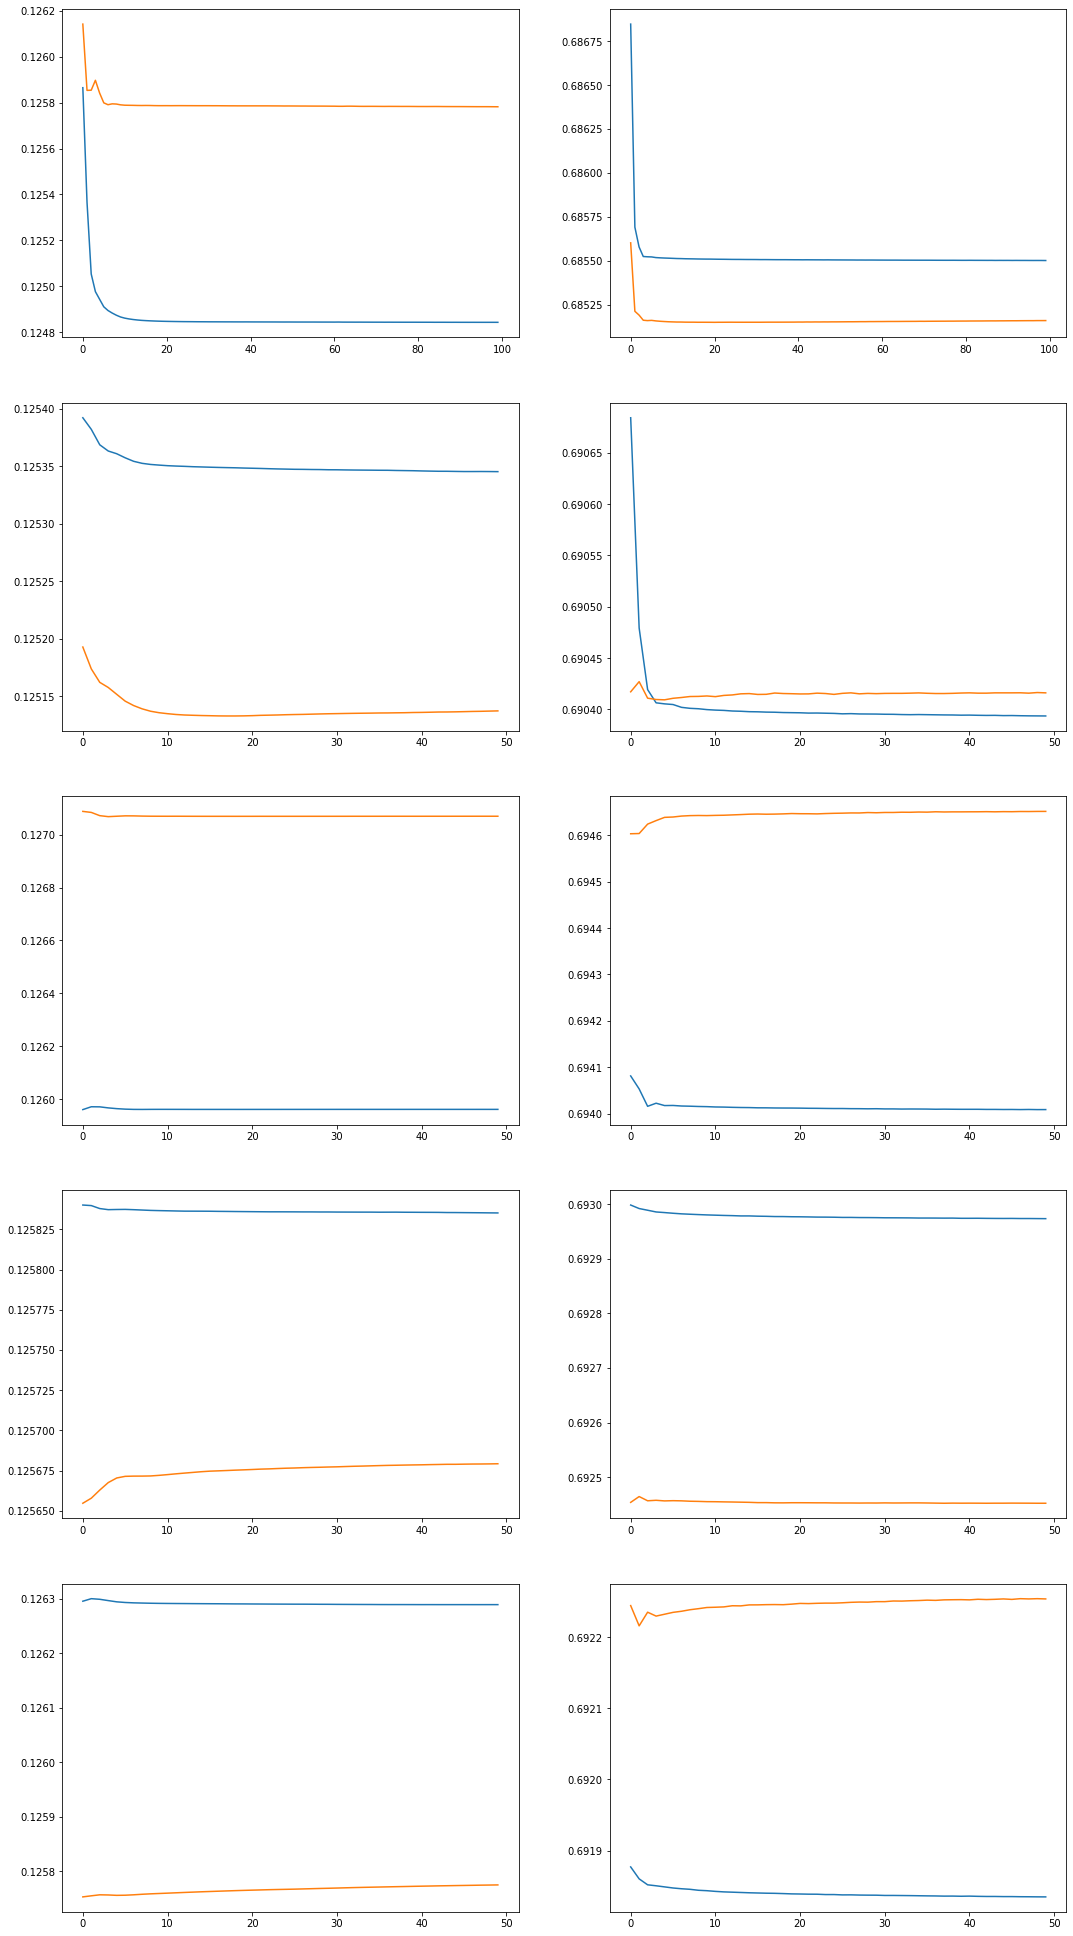

In [59]:
fig,ax = plt.subplots( of_niter, 2, figsize=(18,7*of_niter))

for ofi in range(0,of_niter) :
    
    ax[ofi][0].plot( of_return_dict['train-hist-step1-iter%d' % ofi].history['loss']  )
    ax[ofi][0].plot( of_return_dict['train-hist-step1-iter%d' % ofi].history['val_loss']  )

    ax[ofi][1].plot( of_return_dict['train-hist-step2-iter%d' % ofi].history['loss']  )
    ax[ofi][1].plot( of_return_dict['train-hist-step2-iter%d' % ofi].history['val_loss']  )
    



<function matplotlib.pyplot.show(close=None, block=None)>

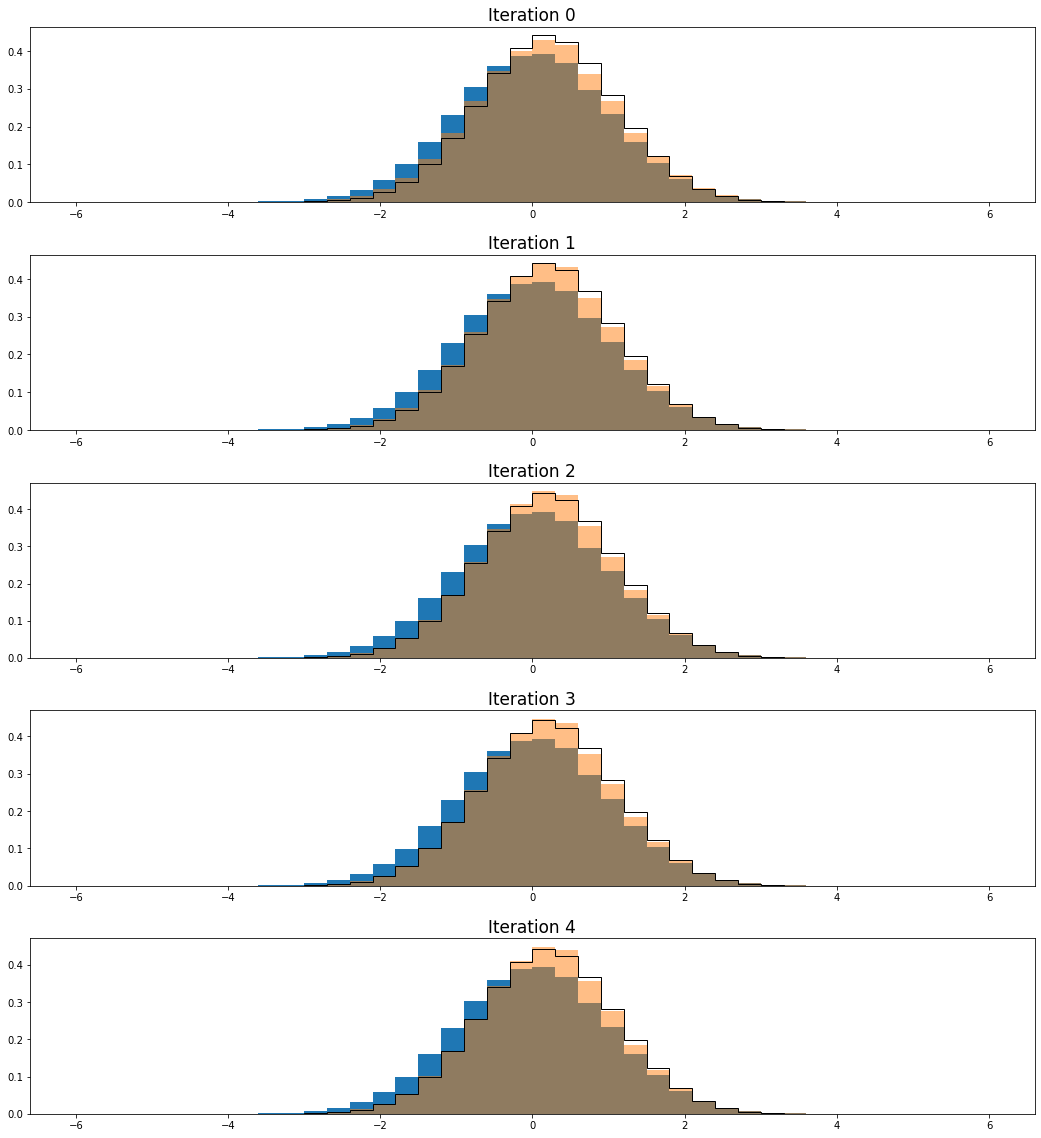

In [60]:


fig,ax = plt.subplots( of_niter, ndim, figsize=(18,4*of_niter))

hmin=-6
hmax=6
hbins=40

hist_data_mc_ofweighted = np.zeros( shape=(of_niter,ndim,hbins))
hist_data_truth         = np.zeros( shape=(of_niter,ndim,hbins))

lfontsize = 17

plt.subplots_adjust( hspace=0.30)
plt.subplots_adjust( wspace=0.25)

do_renorm = True


for ofi in range(0,of_niter) :

    if do_renorm :
        
        for di in range(ndim) :
            
            if ndim > 1 :
                thisax = ax[ofi][di]
            else :
                thisax = ax[ofi]
            
            thisax.hist( train_pts[:,di], bins=hbins, density=True, range=[hmin,hmax], label='train particle' )
            hist_data_mc_ofweighted[ofi,di],_,_ = thisax.hist( train_pts[:,di], weights=push_weights[ofi], bins=hbins, density=True, range=[hmin,hmax], label='OF weighted particle', alpha=0.5 )            
            hist_data_truth[ofi,di],_,_ =         thisax.hist( true_pts10x[:,di], weights=true_pts10x_weights, bins=hbins, density=True, range=[hmin,hmax], label='true particle', histtype='step', color='black' )

    else :
        
        for di in range(ndim) :

            if ndim > 1 :
                thisax = ax[ofi][di]
            else :
                thisax = ax[ofi]
                
            hist_data_mc_ofweighted[ofi,di],_,_ = thisax.hist( train_pts[:,di], weights=push_weights_scaled[ofi], bins=hbins, range=[hmin,hmax], label='OF weighted particle', alpha=0.5 )            
            hist_data_truth[ofi,di],_,_ =         thisax.hist( true_pts10x[:,di], weights=true_pts10x_weights, bins=hbins, range=[hmin,hmax], label='true particle', histtype='step', color='black' )
        

    
    #ax[ofi][0].legend(loc='best', fontsize=13)
    #ax[ofi][1].legend(loc='best', fontsize=13)
    
    
#    ax[ofi][0].set_xlabel('Feature 0', fontsize=lfontsize )
    
#    ax[ofi][1].set_xlabel('Feature 1', fontsize=lfontsize )
 
    if ndim > 1 :
        thisax = ax[ofi][0]
    else :
        thisax = ax[ofi]
        
    thisax.set_title('Iteration %d' % ofi, fontsize=lfontsize )



plt.show

In [61]:
hist_data_diff = hist_data_mc_ofweighted - hist_data_truth
hist_data_diff2 = hist_data_diff * hist_data_diff

hist_data_sum_diff2 = np.zeros( shape=(of_niter,ndim))

for ofi in range( of_niter ) :
    for di in range( ndim ) :
        hist_data_sum_diff2[ofi,di] = np.sum( hist_data_diff2[ofi,di])


<function matplotlib.pyplot.show(close=None, block=None)>

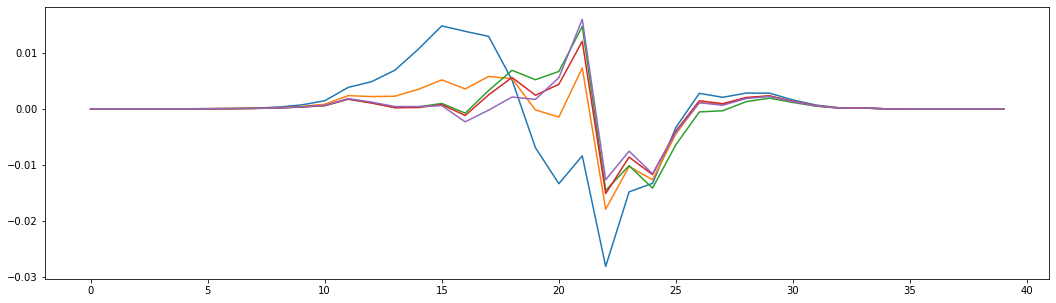

In [62]:
fig,ax = plt.subplots( 1, ndim, figsize=(18,5))

for ofi in range(of_niter) :
    for di in range( ndim ) :
        if ndim > 1 :
            thisax = ax[di]
        else :
            thisax = ax
        thisax.plot(hist_data_diff[ofi,di])

    
plt.show   

<function matplotlib.pyplot.show(close=None, block=None)>

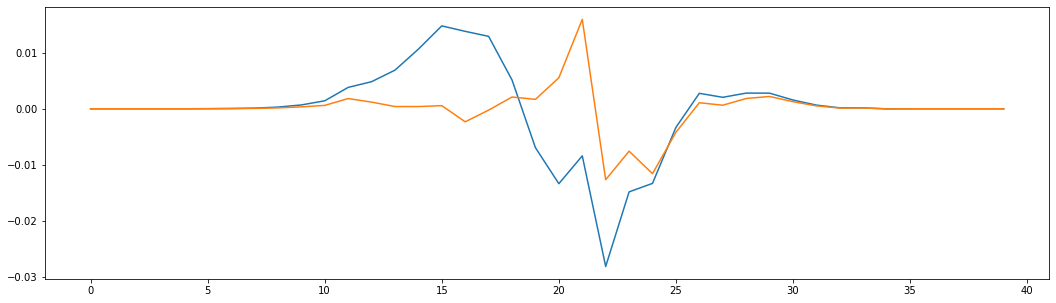

In [63]:
fig,ax = plt.subplots( 1, ndim, figsize=(18,5))

ofi = 0
for di in range( ndim ) :
    if ndim > 1 :
        thisax = ax[di]
    else :
        thisax = ax
    thisax.plot(hist_data_diff[ofi,di])

ofi = of_niter-1
for di in range( ndim ) :
    if ndim > 1 :
        thisax = ax[di]
    else :
        thisax = ax
    thisax.plot(hist_data_diff[ofi,di])
    
plt.show  

<function matplotlib.pyplot.show(close=None, block=None)>

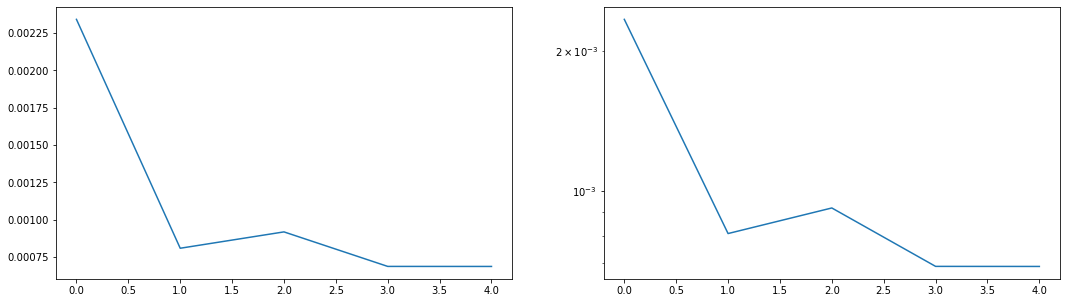

In [64]:
fig,ax = plt.subplots( 1, 2, figsize=(18,5))
ax[0].plot( hist_data_sum_diff2)
ax[1].plot( hist_data_sum_diff2)
ax[1].set_yscale('log')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

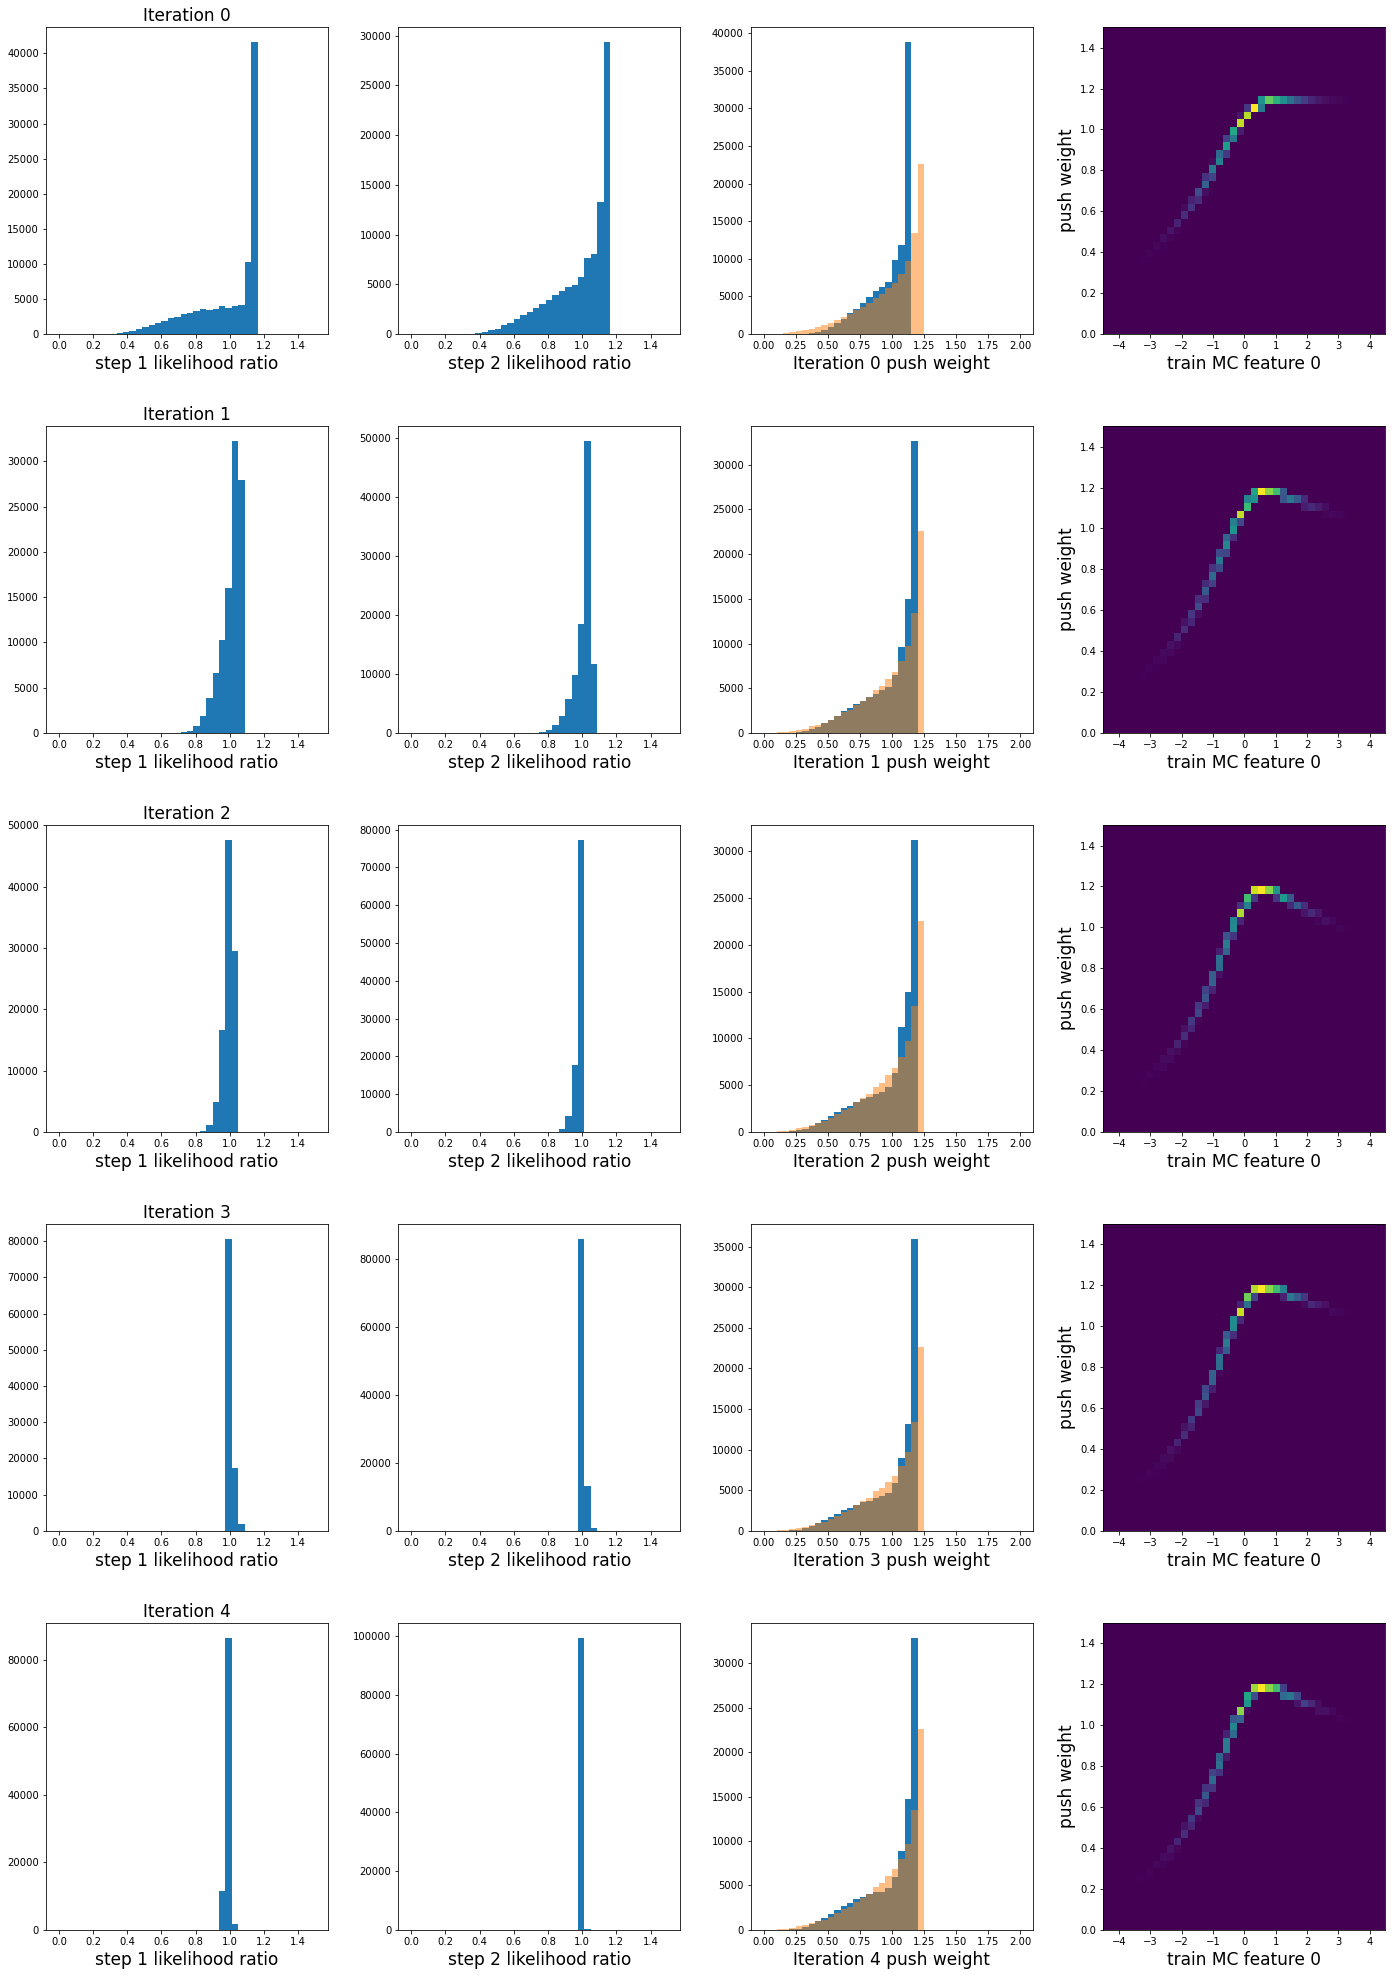

In [65]:
fig,ax = plt.subplots( of_niter, 4, figsize=(24,7*of_niter))

hmin=-6
hmax=6
hbins=40

lfontsize = 17

plt.subplots_adjust( hspace=0.30)
plt.subplots_adjust( wspace=0.25)

for ofi in range(0,of_niter) :

    ax[ofi][0].hist( of_weights[ofi,0,:], bins=hbins, range=[0.,1.5] )
    
    ax[ofi][1].hist( of_weights[ofi,1,:], bins=hbins, range=[0.,1.5] )
    
    ax[ofi][2].hist( push_weights[ofi,:], bins=hbins, range=[0.,2.0] )
    ax[ofi][2].hist( calc_weight, bins=hbins, range=[0.,2.0], alpha=0.5 )
    
    
    #ax[ofi][3].hist2d( of_weights[ofi,0,:], of_weights[ofi,1,:], bins=[hbins,hbins] )

    ax[ofi][3].hist2d( train_pts[:,0], push_weights[ofi,:], 
                      bins=[hbins,hbins], range=([-4.5,4.5],[0.,1.5]) )
    
    
    ax[ofi][0].set_xlabel( 'step 1 likelihood ratio', fontsize=lfontsize )
    
    ax[ofi][1].set_xlabel( 'step 2 likelihood ratio', fontsize=lfontsize )
    
    #ax[ofi][3].set_xlabel( 'step 1 likelihood ratio', fontsize=lfontsize )
    #ax[ofi][3].set_ylabel( 'step 2 likelihood ratio', fontsize=lfontsize )
    
    
    ax[ofi][3].set_xlabel( 'train MC feature 0' , fontsize=lfontsize )
    ax[ofi][3].set_ylabel( 'push weight' , fontsize=lfontsize )
    
    
    
    ax[ofi][2].set_xlabel( 'Iteration %d push weight' % ofi, fontsize=lfontsize )
    
    ax[ofi][0].set_title('Iteration %d' % ofi, fontsize=lfontsize )
    
    
    
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

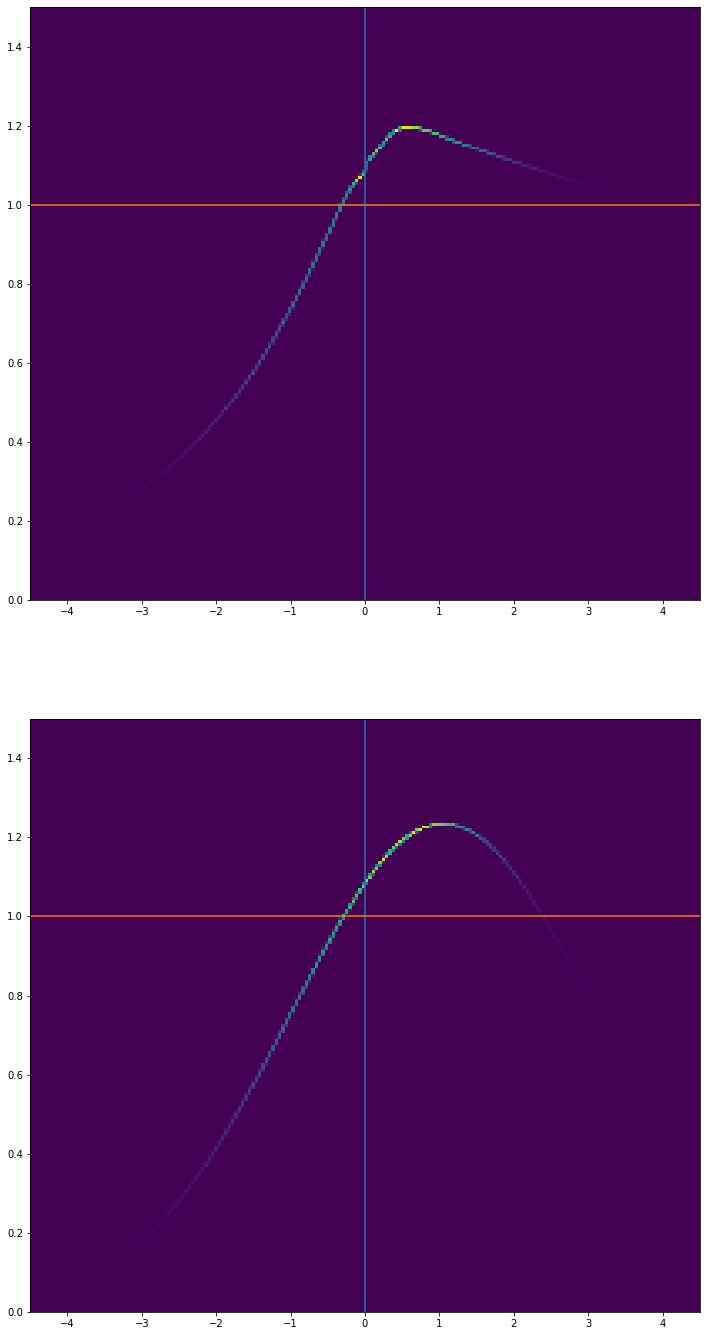

In [66]:
fig,ax = plt.subplots( 2, 1, figsize=(12,2*12))

hbins=200

hpw,_,_,_ = ax[0].hist2d( train_pts[:,0], push_weights[-1,:], 
                      bins=[hbins,hbins], range=([-4.5,4.5],[0.,1.5]) )

hcw,_,_,_ = ax[1].hist2d( train_pts[:,0], calc_weight, 
                      bins=[hbins,hbins], range=([-4.5,4.5],[0.,1.5]) )

ax[0].plot([0,0],[0,1.5])
ax[0].plot([-4.5,4.5],[1,1])

ax[1].plot([0,0],[0,1.5])
ax[1].plot([-4.5,4.5],[1,1])

plt.show

In [67]:
fpw = np.zeros( hpw.shape[0])

for bi0 in range(hpw.shape[0]) :
    esum = 0
    biesum = 0    
    for bi1 in range(hpw.shape[1]) :
        esum += hpw[bi0,bi1]
        biesum += bi1*hpw[bi0,bi1]
        #print(' %3d, %3d :  %8.0f    %8.0f  %8.0f' % (bi0, bi1, hpw[bi1,bi0], esum, biesum))
    wave = 0
    if esum > 0 :
        wave = biesum / esum
    fpw[bi0] = wave
    #print(' %3d : %8.3f' % (bi0, wave))

In [68]:
fcw = np.zeros( hcw.shape[0])

for bi0 in range(hcw.shape[0]) :
    esum = 0
    biesum = 0    
    for bi1 in range(hcw.shape[1]) :
        esum += hcw[bi0,bi1]
        biesum += bi1*hcw[bi0,bi1]
    wave = 0
    if esum > 0 :
        wave = biesum / esum
    fcw[bi0] = wave


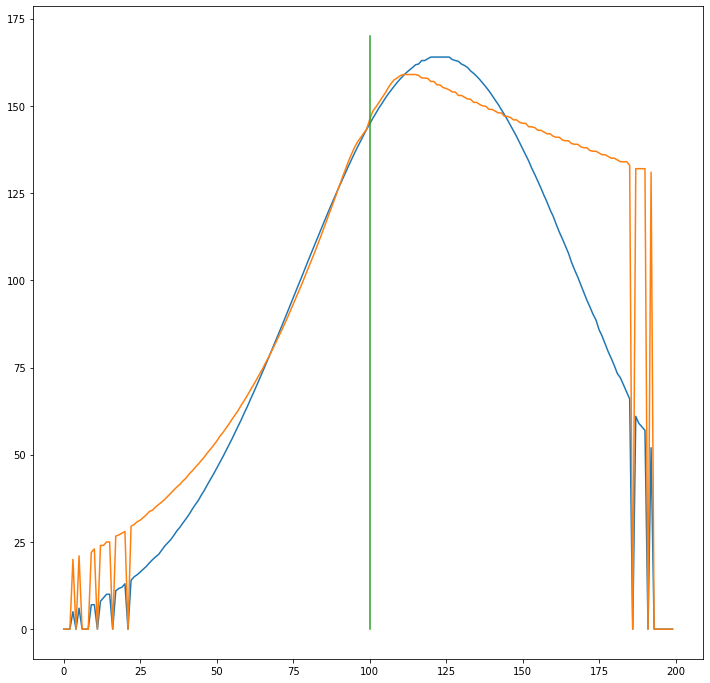

In [69]:
fig,ax = plt.subplots( 1, 1, figsize=(12,12))
ax.plot(fcw)
ax.plot(fpw)
ax.plot([100,100],[0,170])

<function matplotlib.pyplot.show(close=None, block=None)>

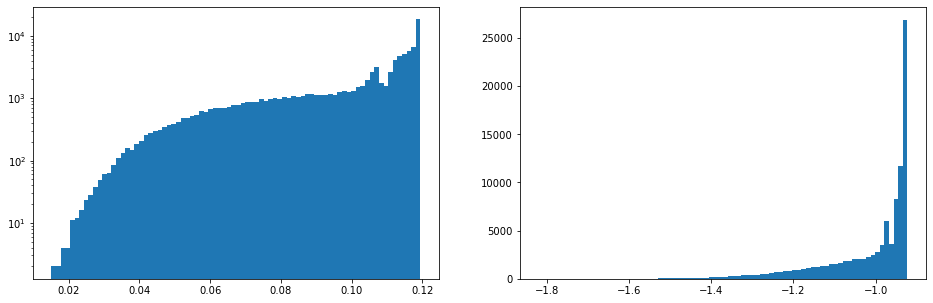

In [70]:
fig,ax = plt.subplots( 1, 2, figsize=(8*2,5))

hbins=80

ax[0].hist( final_push_weights_scaled, bins=hbins)
ax[0].set_yscale('log')

ax[1].hist( np.log10(final_push_weights_scaled), bins=hbins)

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

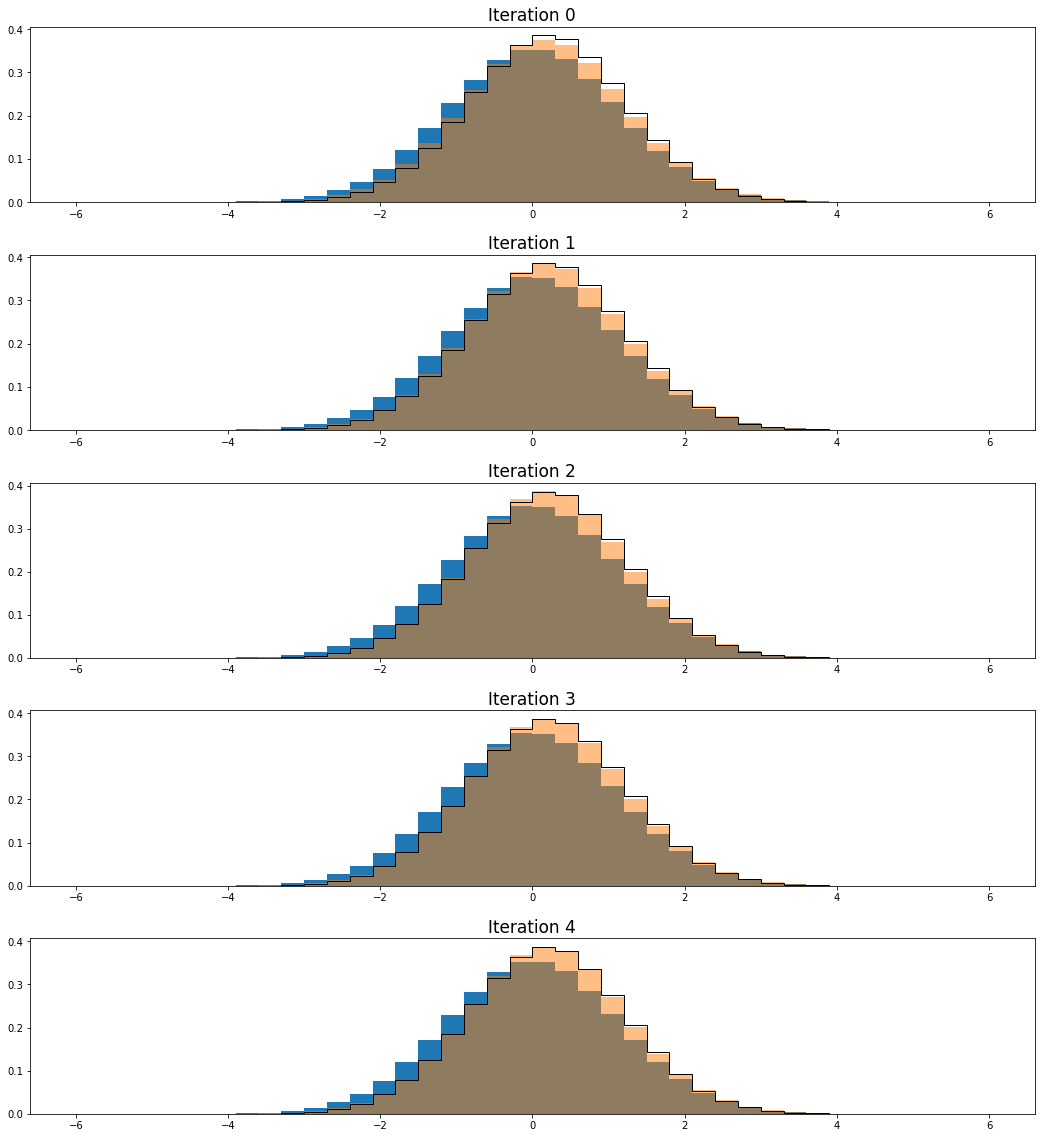

In [71]:

fig,ax = plt.subplots( of_niter, ndim, figsize=(18,4*of_niter))

hmin=-6
hmax=6
hbins=40

det_hist_data_mc_ofweighted = np.zeros( shape=(of_niter,ndim,hbins))
det_hist_data_truth         = np.zeros( shape=(of_niter,ndim,hbins))

lfontsize = 17

plt.subplots_adjust( hspace=0.30)
plt.subplots_adjust( wspace=0.25)

do_renorm = True


for ofi in range(0,of_niter) :

    if do_renorm :
        
        for di in range(ndim) :
            
            if ndim > 1 :
                thisax = ax[ofi][di]
            else :
                thisax = ax[ofi]
            
            thisax.hist( train_det_pts[:,di], bins=hbins, density=True, range=[hmin,hmax], label='train particle' )
            det_hist_data_mc_ofweighted[ofi,di],_,_ = thisax.hist( train_det_pts[:,di], weights=push_weights[ofi], bins=hbins, density=True, range=[hmin,hmax], label='OF weighted particle', alpha=0.5 )
            det_hist_data_truth[ofi,di],_,_ =         thisax.hist( true_det_pts10x[:,di], weights=true_pts10x_weights, bins=hbins, density=True, range=[hmin,hmax], label='true particle', histtype='step', color='black' )

    else :
        
        for di in range(ndim) :

            if ndim > 1 :
                thisax = ax[ofi][di]
            else :
                thisax = ax[ofi]
        
            det_hist_data_mc_ofweighted[ofi,di],_,_ = thisax.hist( train_det_pts[:,di], weights=push_weights_scaled[ofi], bins=hbins, range=[hmin,hmax], label='OF weighted particle', alpha=0.5 )
            det_hist_data_truth[ofi,di],_,_ =         thisax.hist( true_det_pts10x[:,di], weights=true_pts10x_weights, bins=hbins, range=[hmin,hmax], label='true particle', histtype='step', color='black' )
        

    
    #ax[ofi][0].legend(loc='best', fontsize=13)
    #ax[ofi][1].legend(loc='best', fontsize=13)
    
    
#    ax[ofi][0].set_xlabel('Feature 0', fontsize=lfontsize )
    
#    ax[ofi][1].set_xlabel('Feature 1', fontsize=lfontsize )
    
    if ndim > 1 :
        thisax = ax[ofi][0]
    else :
        thisax = ax[ofi]
    
    thisax.set_title('Iteration %d' % ofi, fontsize=lfontsize )



plt.show

In [72]:
det_hist_data_diff = det_hist_data_mc_ofweighted - det_hist_data_truth
det_hist_data_diff2 = det_hist_data_diff * det_hist_data_diff

det_hist_data_sum_diff2 = np.zeros( shape=(of_niter,ndim))

for ofi in range( of_niter ) :
    for di in range( ndim ) :
        det_hist_data_sum_diff2[ofi,di] = np.sum( det_hist_data_diff2[ofi,di])


<function matplotlib.pyplot.show(close=None, block=None)>

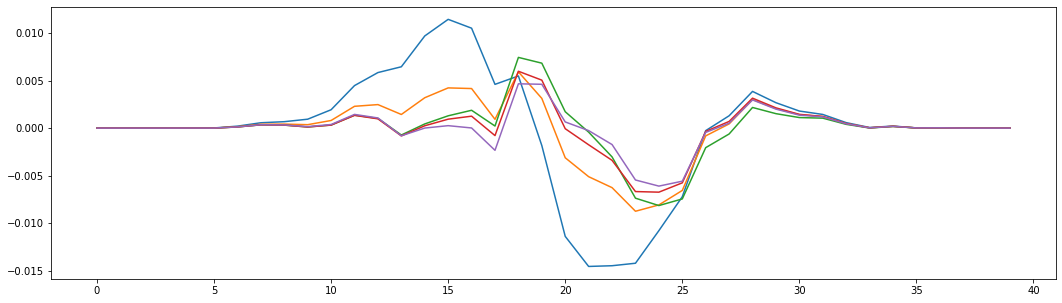

In [73]:
fig,ax = plt.subplots( 1, ndim, figsize=(18,5))

for ofi in range(of_niter) :
    for di in range( ndim ) :
        if ndim > 1 :
            thisax = ax[di]
        else :
            thisax = ax
        thisax.plot(det_hist_data_diff[ofi,di])

    
plt.show   

<function matplotlib.pyplot.show(close=None, block=None)>

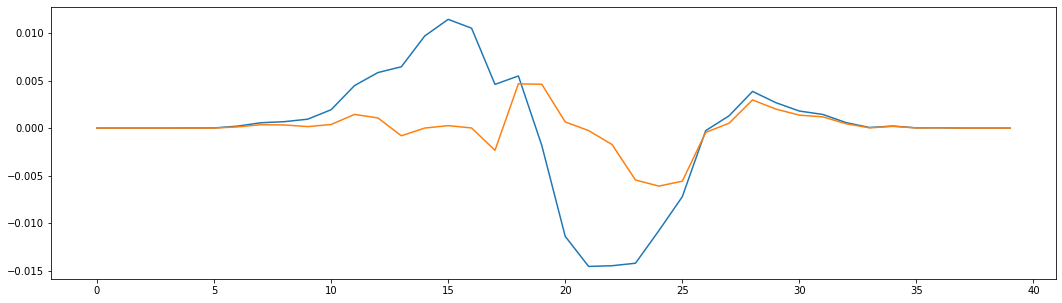

In [74]:
fig,ax = plt.subplots( 1, ndim, figsize=(18,5))

ofi = 0
for di in range( ndim ) :
    if ndim > 1 :
        thisax = ax[di]
    else :
        thisax = ax
    thisax.plot(det_hist_data_diff[ofi,di])

ofi = of_niter-1
for di in range( ndim ) :
    if ndim > 1 :
        thisax = ax[di]
    else :
        thisax = ax
    thisax.plot(det_hist_data_diff[ofi,di])

    
plt.show  

<function matplotlib.pyplot.show(close=None, block=None)>

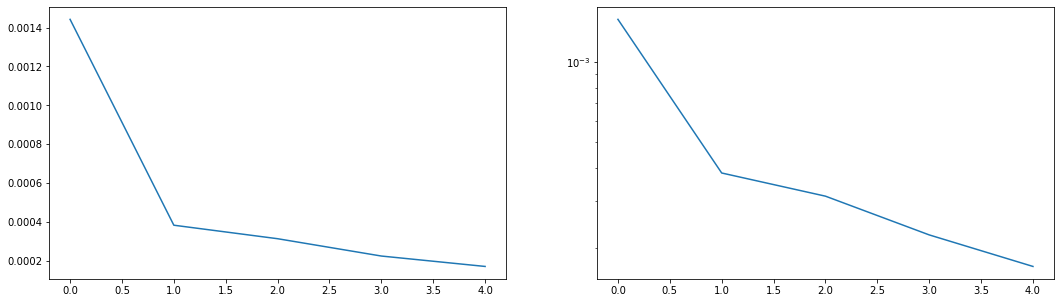

In [75]:
fig,ax = plt.subplots( 1, 2, figsize=(18,5))
ax[0].plot( det_hist_data_sum_diff2)
ax[1].plot( det_hist_data_sum_diff2)
ax[1].set_yscale('log')
plt.show

In [76]:
step1_mean = np.zeros( of_niter )
step1_rms = np.zeros( of_niter )

step2_mean = np.zeros( of_niter )
step2_rms = np.zeros( of_niter )

iter_val = np.zeros( of_niter )

for ofi in range( of_niter ) :
    
    iter_val[ofi] = ofi
    
    step1_mean[ofi] = np.mean( of_weights[ofi,0,:] )
    step1_rms[ofi] = np.sqrt( np.var( of_weights[ofi,0,:]))
    
    step2_mean[ofi] = np.mean( of_weights[ofi,1,:] )
    step2_rms[ofi] = np.sqrt( np.var( of_weights[ofi,1,:]))
    
    print("  iter %2d : step 1 mean  %.3f  rms %.3f      step 2 mean  %.3f  rms %.3f" % 
          (ofi, step1_mean[ofi], step1_rms[ofi], step2_mean[ofi], step2_rms[ofi]) )

  iter  0 : step 1 mean  0.990  rms 0.195      step 2 mean  0.989  rms 0.167
  iter  1 : step 1 mean  1.007  rms 0.058      step 2 mean  1.007  rms 0.049
  iter  2 : step 1 mean  0.992  rms 0.029      step 2 mean  0.989  rms 0.025
  iter  3 : step 1 mean  1.006  rms 0.016      step 2 mean  1.006  rms 0.010
  iter  4 : step 1 mean  0.992  rms 0.013      step 2 mean  0.992  rms 0.007


<function matplotlib.pyplot.show(close=None, block=None)>

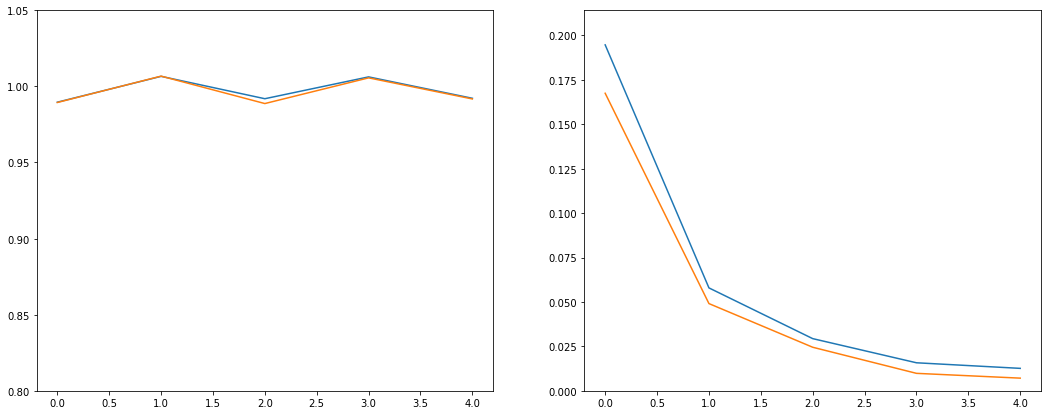

In [77]:
fig,ax = plt.subplots( 1, 2, figsize=(18,7))

ax[0].plot( iter_val, step1_mean )
ax[0].plot( iter_val, step2_mean )
ax[0].set_ylim( 0.80, 1.05)

ax[1].plot( iter_val, step1_rms )
ax[1].plot( iter_val, step2_rms )
ax[1].set_ylim( 0, 1.1*np.max(step1_rms))


plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

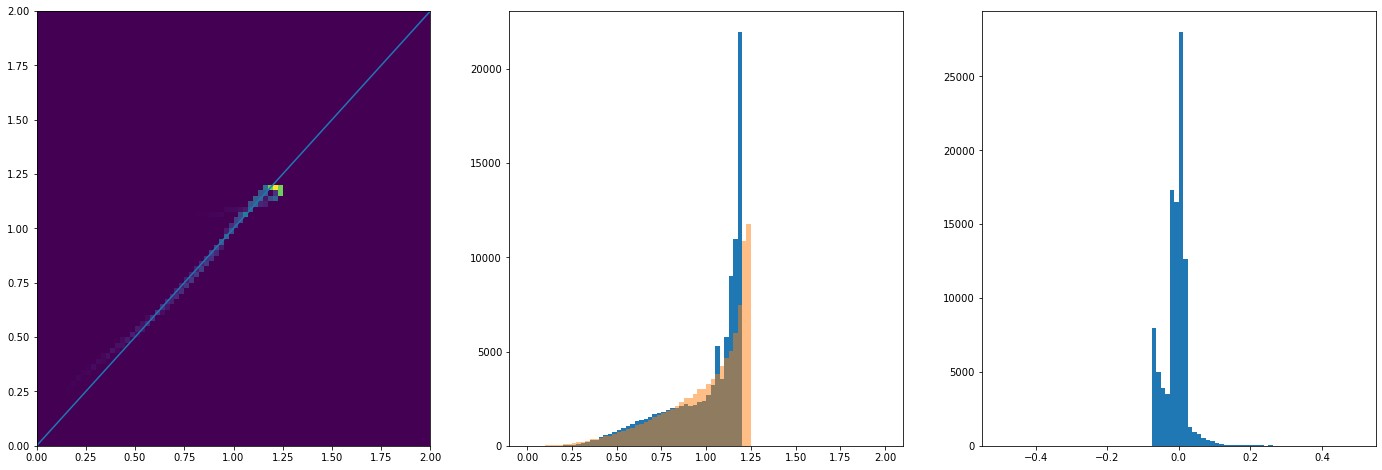

In [78]:
fig,ax = plt.subplots( 1, 3, figsize=(3*8,1*8))
max_weight = 2.0

ax[0].hist2d( calc_weight, final_push_weights, bins=[80,80], range=([0,max_weight],[0,max_weight]))
ax[0].plot([0,max_weight],[0,max_weight])

ax[1].hist( final_push_weights, bins=80, range=[0,max_weight] )
ax[1].hist( calc_weight, bins=80, range=[0,max_weight], alpha=0.5 )

ax[2].hist( final_push_weights-calc_weight, bins=80, range=[-0.5,0.5] )

plt.show

In [79]:

delta_weight_rms = np.sqrt( np.var( np.clip(final_push_weights-calc_weight,-0.5,0.5 ) ) )
print('\n\n Delta weight RMS:  %.5f\n\n' % delta_weight_rms )



 Delta weight RMS:  0.03428




## Monitoring of the OmniFold internal details

In [80]:
def profile2d( axis, xvals, yvals, hbins, hrange, drawhist=True, drawline=False, drawcurve=True ) :
    
    hist_data = axis.hist2d( xvals, yvals, bins=hbins, range=hrange)
    
    if not drawhist :
        axis.cla()

    nybins = len(hist_data[0][0])
    print("number of y bins: %d" % nybins)

    nxbins = len(hist_data[0])
    print("number of x bins: %d" % nxbins)



    x_vals = np.zeros( nxbins )
    avey_vals = np.zeros( nxbins )
    rmsy_vals = np.zeros( nxbins )

    for xbi in range( nxbins ) :

        wsum = 0
        ywsum = 0
        yywsum = 0

        xval = 0.5 * ( hist_data[1][xbi] + hist_data[1][xbi+1] )
        #print(" xbin %d has center at %6.3f" % ( xbin_ind, xval ))

        for ybi in range( nybins ) :  
            yval = 0.5 * ( hist_data[2][ybi] + hist_data[2][ybi+1] )
            bin_content = hist_data[0][xbi][ybi]
            wsum = wsum + bin_content
            ywsum = ywsum + yval * bin_content
            yywsum = yywsum + yval * yval * bin_content
            #print("  %3d : y = %6.3f  bin content = %7d" % (bi, yval, bin_content))

        ave_y = ywsum / wsum
        ave_yy = yywsum / wsum
        rms_y = ave_yy - ave_y * ave_y
        #print(" Ave y = %.3f, RMS y = %.3f" % ( ave_y, rms_y) )

        x_vals[xbi] = xval
        avey_vals[xbi] = ave_y
        rmsy_vals[xbi] = rms_y


    #for xbi in range( nxbins ) :
        #print("  %4d :  x = %7.3f   ave y = %7.3f  rms y = %7.3f" % ( xbi, x_vals[xbi], avey_vals[xbi], rmsy_vals[xbi]))

    if drawline :
        axis.plot( (hist_data[1][0], hist_data[1][-1]), (0,0) )  
    
    if drawcurve :
        axis.errorbar( x_vals, avey_vals, yerr=rmsy_vals, fmt='-', linewidth=5)

    
    plt.show
    
    return x_vals, avey_vals, rmsy_vals

In [81]:
of_return_dict

{'train-hist-step1-iter0': <keras.src.callbacks.history.History at 0x774e8cd9b940>,
 'model_weights_step1_iter0': array([[ 0.2806186 ,  0.2586868 ,  0.08613718,  0.15511213,  0.0647069 ,
         -0.02945239,  0.05180968,  0.2640923 , -0.05175112, -0.28887913,
          0.31774622, -0.23389503, -0.12579511, -0.14183232,  0.06842198,
         -0.07819022, -0.28511927,  0.02371447,  0.32066312, -0.01647225,
         -0.27362195,  0.18709306, -0.35374588,  0.06919864, -0.27202132,
         -0.3426725 ,  0.13023119, -0.28594202, -0.11749037, -0.24800369,
         -0.12022403, -0.19941965, -0.32127962,  0.3041872 ,  0.11945339,
         -0.19361988,  0.09675028, -0.03097362, -0.14055537,  0.2365157 ,
          0.01457175,  0.01815956,  0.3367933 , -0.22950448,  0.17130387,
          0.2610663 , -0.05977238,  0.02396486, -0.00386451, -0.13671862]],
       dtype=float32),
 'model_biases_step1_iter0': array([-9.3885176e-03,  3.9193383e-03, -1.1036226e-02,  1.5069372e-02,
         1.9433567e-02

In [82]:
of_return_dict['weights'].shape

(5, 2, 100000)

In [83]:
of_return_dict['weights'][0,1,:]

array([1.1354254 , 0.90589166, 0.92837964, ..., 1.07007823, 1.10679641,
       0.86827914])

In [84]:
of_return_dict['push_weights'][0]

array([1.1354254 , 0.90589166, 0.92837964, ..., 1.07007823, 1.10679641,
       0.86827914])

In [85]:
of_return_dict['ensemble_weights'].shape

(5, 5, 2, 100000)

In [86]:
ensemble_of_prob = of_return_dict['ensemble_weights'] / (1. + of_return_dict['ensemble_weights'])

In [87]:
train_pts[:,0].shape

(100000,)

In [88]:
of_prob = of_return_dict['weights'] / (1. + of_return_dict['weights'] )

In [89]:
of_prob

array([[[0.5311059 , 0.4686028 , 0.38067475, ..., 0.5323451 ,
         0.52973895, 0.48497077],
        [0.53170923, 0.4753112 , 0.48142991, ..., 0.51692647,
         0.52534569, 0.46474808]],

       [[0.49700498, 0.4988538 , 0.47249256, ..., 0.51288033,
         0.51196436, 0.50353012],
        [0.50122279, 0.5000277 , 0.50196216, ..., 0.50927968,
         0.51286666, 0.49655015]],

       [[0.49369552, 0.49729759, 0.48410028, ..., 0.50446866,
         0.50517168, 0.49988336],
        [0.49416726, 0.49745133, 0.49842656, ..., 0.50295191,
         0.50276629, 0.49567312]],

       [[0.51017684, 0.5016507 , 0.5003106 , ..., 0.49497614,
         0.49468727, 0.50201194],
        [0.50663186, 0.50061768, 0.50058721, ..., 0.5007303 ,
         0.49973582, 0.50068697]],

       [[0.4964525 , 0.49401107, 0.49965015, ..., 0.50198694,
         0.50214017, 0.49298708],
        [0.49752854, 0.49507401, 0.49515801, ..., 0.49842424,
         0.50023167, 0.49536182]]])

number of y bins: 2000
number of x bins: 200


/tmp/ipykernel_3822978/1279626419.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_3822978/1279626419.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 2000
number of x bins: 200
number of y bins: 2000
number of x bins: 200
number of y bins: 2000
number of x bins: 200
number of y bins: 2000
number of x bins: 200


<function matplotlib.pyplot.show(close=None, block=None)>

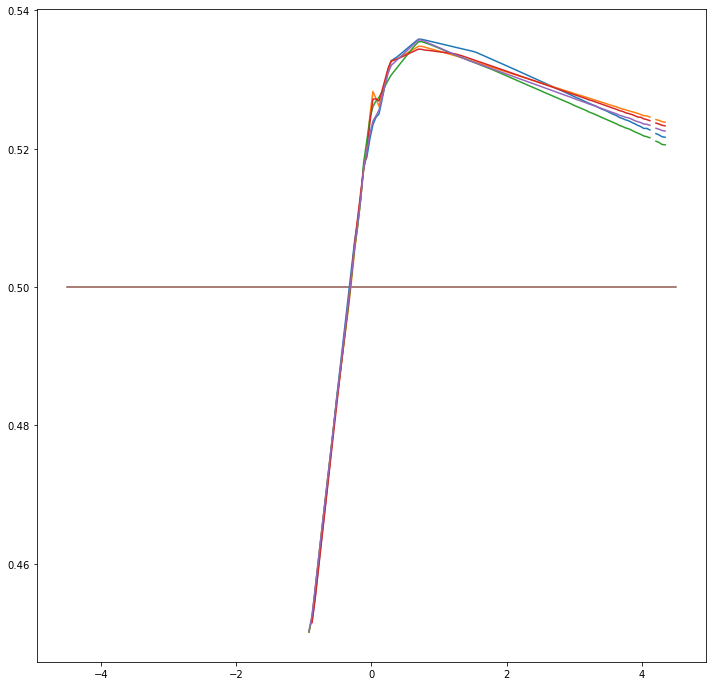

In [90]:

xmin = -4.5
xmax = 4.5

ymin = 0.45
ymax = 0.6

fig,ax = plt.subplots( 1, 1, figsize=(12,12))

axi = ax

x = np.zeros(shape=(n_models_to_ensemble,200))
y = np.zeros(shape=(n_models_to_ensemble,200))
e = np.zeros(shape=(n_models_to_ensemble,200))



for ei in range(n_models_to_ensemble) :
    x[ei,:],y[ei,:],e[ei,:] = profile2d( axi, train_det_pts[:,0], ensemble_of_prob[ei,0,0,:], 
      hbins=[200,2000], hrange=([xmin,xmax],[ymin,ymax]), drawhist=False, drawline=False, drawcurve=False ) 

for ei in range(n_models_to_ensemble) :
    axi.errorbar( x[ei,:], y[ei,:], e[ei,:])




axi.plot([xmin,xmax],[0.5,0.5])


plt.show

number of y bins: 2000
number of x bins: 200


/tmp/ipykernel_3822978/1279626419.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_3822978/1279626419.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 2000
number of x bins: 200


/tmp/ipykernel_3822978/1279626419.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_3822978/1279626419.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 2000
number of x bins: 200


...

number of y bins: 2000
number of x bins: 200


/tmp/ipykernel_3822978/1279626419.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_3822978/1279626419.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 2000
number of x bins: 200


/tmp/ipykernel_3822978/1279626419.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_3822978/1279626419.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


<function matplotlib.pyplot.show(close=None, block=None)>

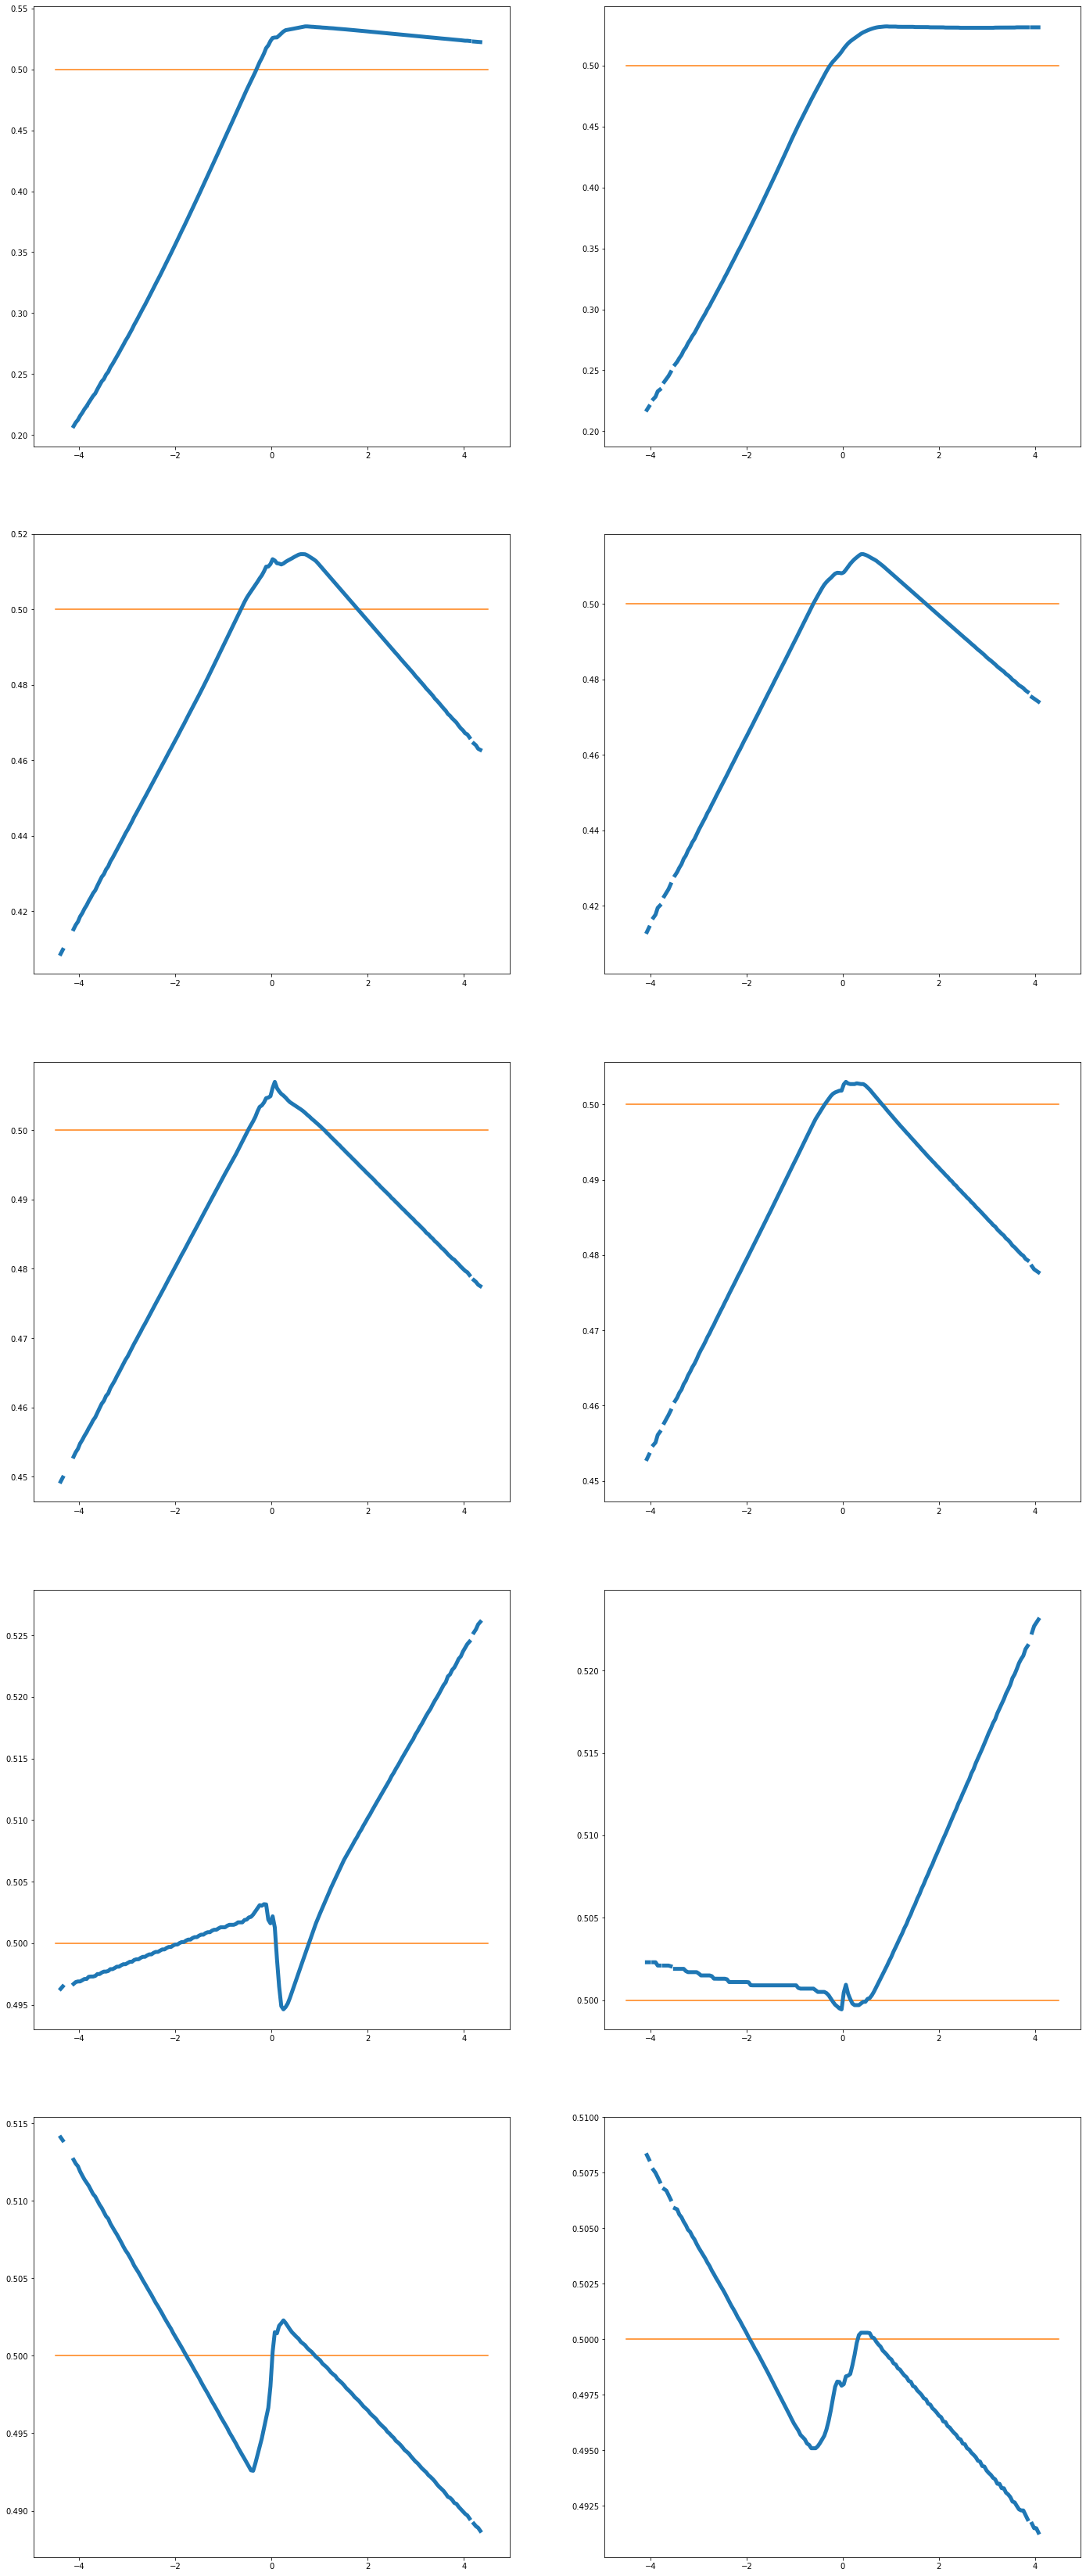

In [91]:
fig,ax = plt.subplots( of_niter, 2, figsize=(2*12,of_niter*12))

xmin = -4.5
xmax = 4.5

ymin = 0.2
ymax = 0.6

for ofi in range( of_niter ) :

    profile2d( ax[ofi][0], train_det_pts[:,0], of_prob[ofi,0,:], 
          hbins=[200,2000], hrange=([xmin,xmax],[ymin,ymax]), drawhist=False, drawline=False ) 
    ax[ofi][0].plot([xmin,xmax],[0.5,0.5])
    
    profile2d( ax[ofi][1], train_pts[:,0], of_prob[ofi,1,:], 
          hbins=[200,2000], hrange=([-4.5,4.5],[ymin,ymax]), drawhist=False, drawline=False ) 
    ax[ofi][1].plot([xmin,xmax],[0.5,0.5])

plt.show

In [92]:
def prob_from_hists( points_a, points_b, weights_a, weights_b, hnbins, hxmin, hxmax ) :
    
    hbw = (hxmax-hxmin)/hnbins
    
    #-- calculate bin indices
    bin_indices_a = np.array( (points_a - hxmin)/hbw, dtype=int )
    bin_indices_b = np.array( (points_b - hxmin)/hbw, dtype=int )
    
    
    hist_binsum_a = np.zeros( hnbins )
    hist_binsum_b = np.zeros( hnbins )
    
    hist_err_a = np.zeros( hnbins )
    hist_err_b = np.zeros( hnbins )
    
    hist_ratio = np.zeros( hnbins )
    hist_ratio_err = np.zeros( hnbins )
    
    sample_wsum_a = np.sum(weights_a)
    sample_wsum_b = np.sum(weights_b)

    
    for bi in range( hnbins ) :
        hist_binsum_a[bi] = np.sum( weights_a[ bin_indices_a == bi ] ) / sample_wsum_a
        hist_binsum_b[bi] = np.sum( weights_b[ bin_indices_b == bi ] ) / sample_wsum_b
        hist_err_a[bi] = np.sqrt( np.sum( np.square( weights_a[ bin_indices_a == bi ] ) ) ) / sample_wsum_a
        hist_err_b[bi] = np.sqrt( np.sum( np.square( weights_b[ bin_indices_b == bi ] ) ) ) / sample_wsum_b
        if hist_binsum_b[bi] > 0 :
            hist_ratio[bi] = hist_binsum_b[bi] / (hist_binsum_a[bi] + hist_binsum_b[bi])
            if hist_binsum_a[bi] > 0 :
                hist_ratio_err[bi] = np.sqrt(
                    np.square( (hist_binsum_b[bi]/np.square(hist_binsum_b[bi]+hist_binsum_a[bi])) * hist_err_a[bi] ) +
                    np.square( (hist_binsum_a[bi]/np.square(hist_binsum_b[bi]+hist_binsum_a[bi])) * hist_err_b[bi] )
                )
        
    return_dict = {}
    return_dict['hist_binsum_a'] = hist_binsum_a
    return_dict['hist_binsum_b'] = hist_binsum_b
    return_dict['hist_err_a'] = hist_err_a
    return_dict['hist_err_b'] = hist_err_b
    return_dict['hist_ratio'] = hist_ratio
    return_dict['hist_ratio_err'] = hist_ratio_err
    
    return return_dict
    

## Examine the Likelihood Ratio output for Step 1 in OmniFold for each iteration

number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_3822978/1279626419.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_3822978/1279626419.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_3822978/1279626419.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_3822978/1279626419.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 1000
number of x bins: 1000


...

number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_3822978/1279626419.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_3822978/1279626419.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_3822978/1279626419.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_3822978/1279626419.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


<function matplotlib.pyplot.show(close=None, block=None)>

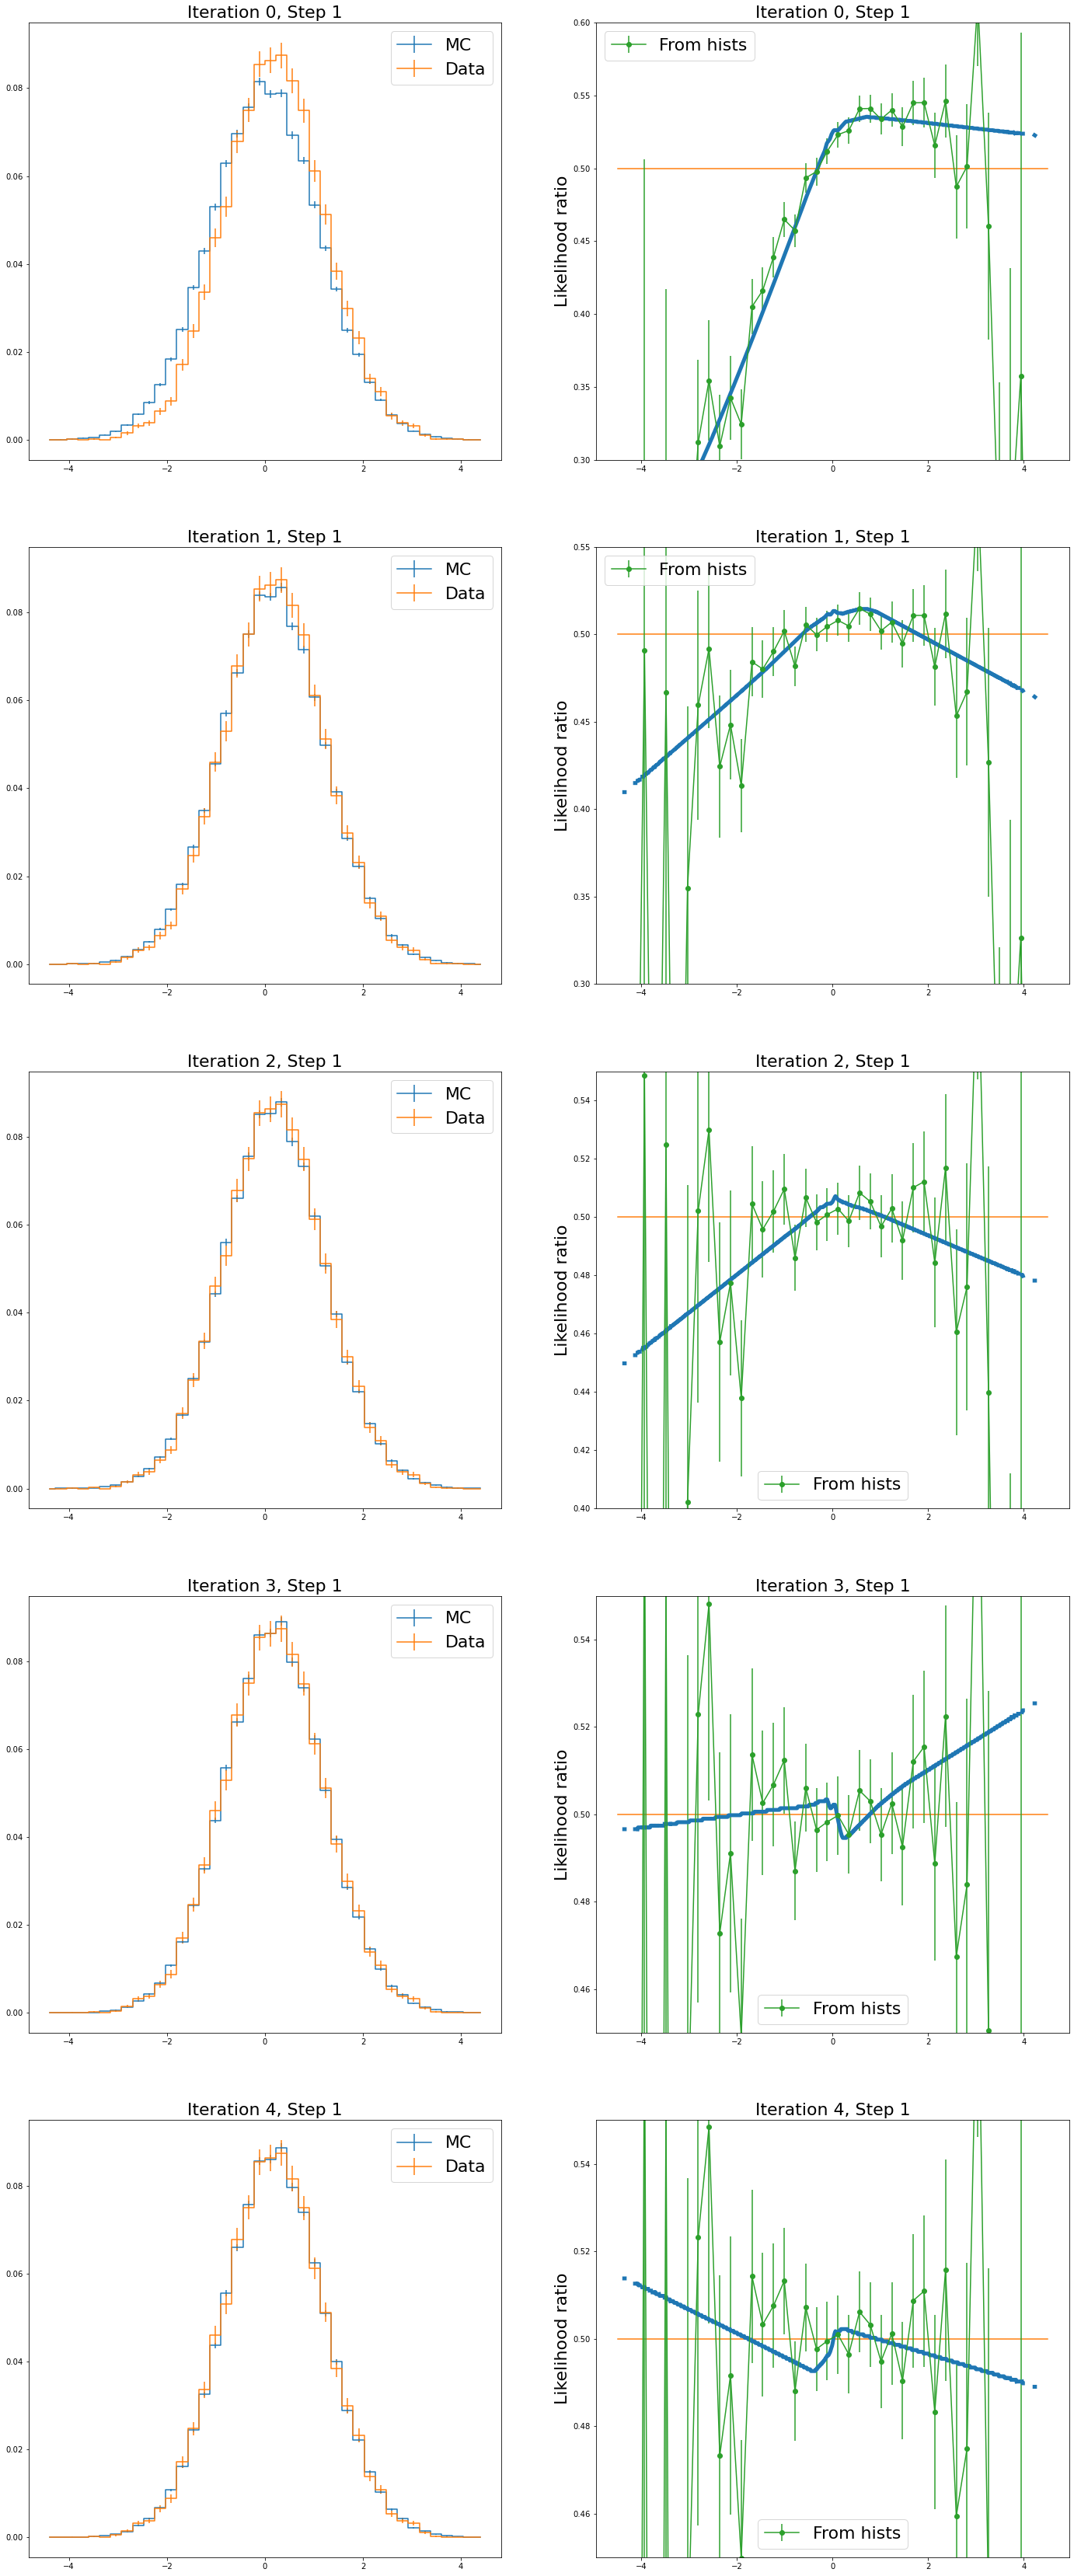

In [93]:

hxmin = -4.5
hxmax = 4.5


hnbins = 40



hbw = (hxmax-hxmin) / hnbins

xvals = np.zeros( hnbins )
for bi in range( hnbins ) :
    xvals[bi] = hxmin + (0.5 + bi)*hbw

nnbins = 1000

plotymin=[0.30, 0.30, 0.40, 0.45, 0.45]
plotymax=[0.60, 0.55, 0.55, 0.55, 0.55]


#plotymin=[0.30, 0.45, 0.49, 0.49, 0.49]
#plotymax=[0.60, 0.55, 0.51, 0.51, 0.51]



fig,ax = plt.subplots( of_niter, 2, figsize=(2*12,of_niter*12))


for ofi in range( of_niter ) :
    
    weights_ones_b = np.ones( len(true_det_pts[:,0]) )

    if ofi==0 :        
        weights_a = np.ones( len(train_det_pts[:,0]) )        
    else :
        weights_a = of_return_dict['push_weights'][ofi-1]

    rd = prob_from_hists( train_det_pts[:,0], 
                             true_det_pts[:,0], 
                             weights_a, 
                             weights_ones_b, 
                             hnbins, hxmin, hxmax )

    axi = ax[ofi][0]
    axi.errorbar( xvals, rd['hist_binsum_a'], rd['hist_err_a'], drawstyle='steps-mid', label='MC')
    axi.errorbar( xvals, rd['hist_binsum_b'], rd['hist_err_b'], drawstyle='steps-mid', label='Data')
    axi.legend( fontsize=22 )
    axi.set_title('Iteration %d, Step 1' % ofi, fontsize=22 )
        
    axi = ax[ofi][1]
    profile2d( axi, train_det_pts[:,0], of_prob[ofi,0,:], 
          hbins=[nnbins,nnbins], hrange=([xmin,xmax],[ymin,ymax]), drawhist=False, drawline=False ) 
    axi.plot([hxmin,hxmax],[0.5,0.5])
    axi.errorbar(xvals,rd['hist_ratio'],rd['hist_ratio_err'], marker='o', linestyle='-', label='From hists')
    axi.legend( fontsize=22 )
    axi.set_ylabel('Likelihood ratio', fontsize=22 )
    
    axi.set_ylim( plotymin[ofi], plotymax[ofi] )
    axi.set_title('Iteration %d, Step 1' % ofi, fontsize=22 )
        

        
        
plt.show

number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_3822978/1279626419.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_3822978/1279626419.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_3822978/1279626419.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_3822978/1279626419.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 1000
number of x bins: 1000


...

number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_3822978/1279626419.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_3822978/1279626419.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


number of y bins: 1000
number of x bins: 1000


/tmp/ipykernel_3822978/1279626419.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_3822978/1279626419.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


<function matplotlib.pyplot.show(close=None, block=None)>

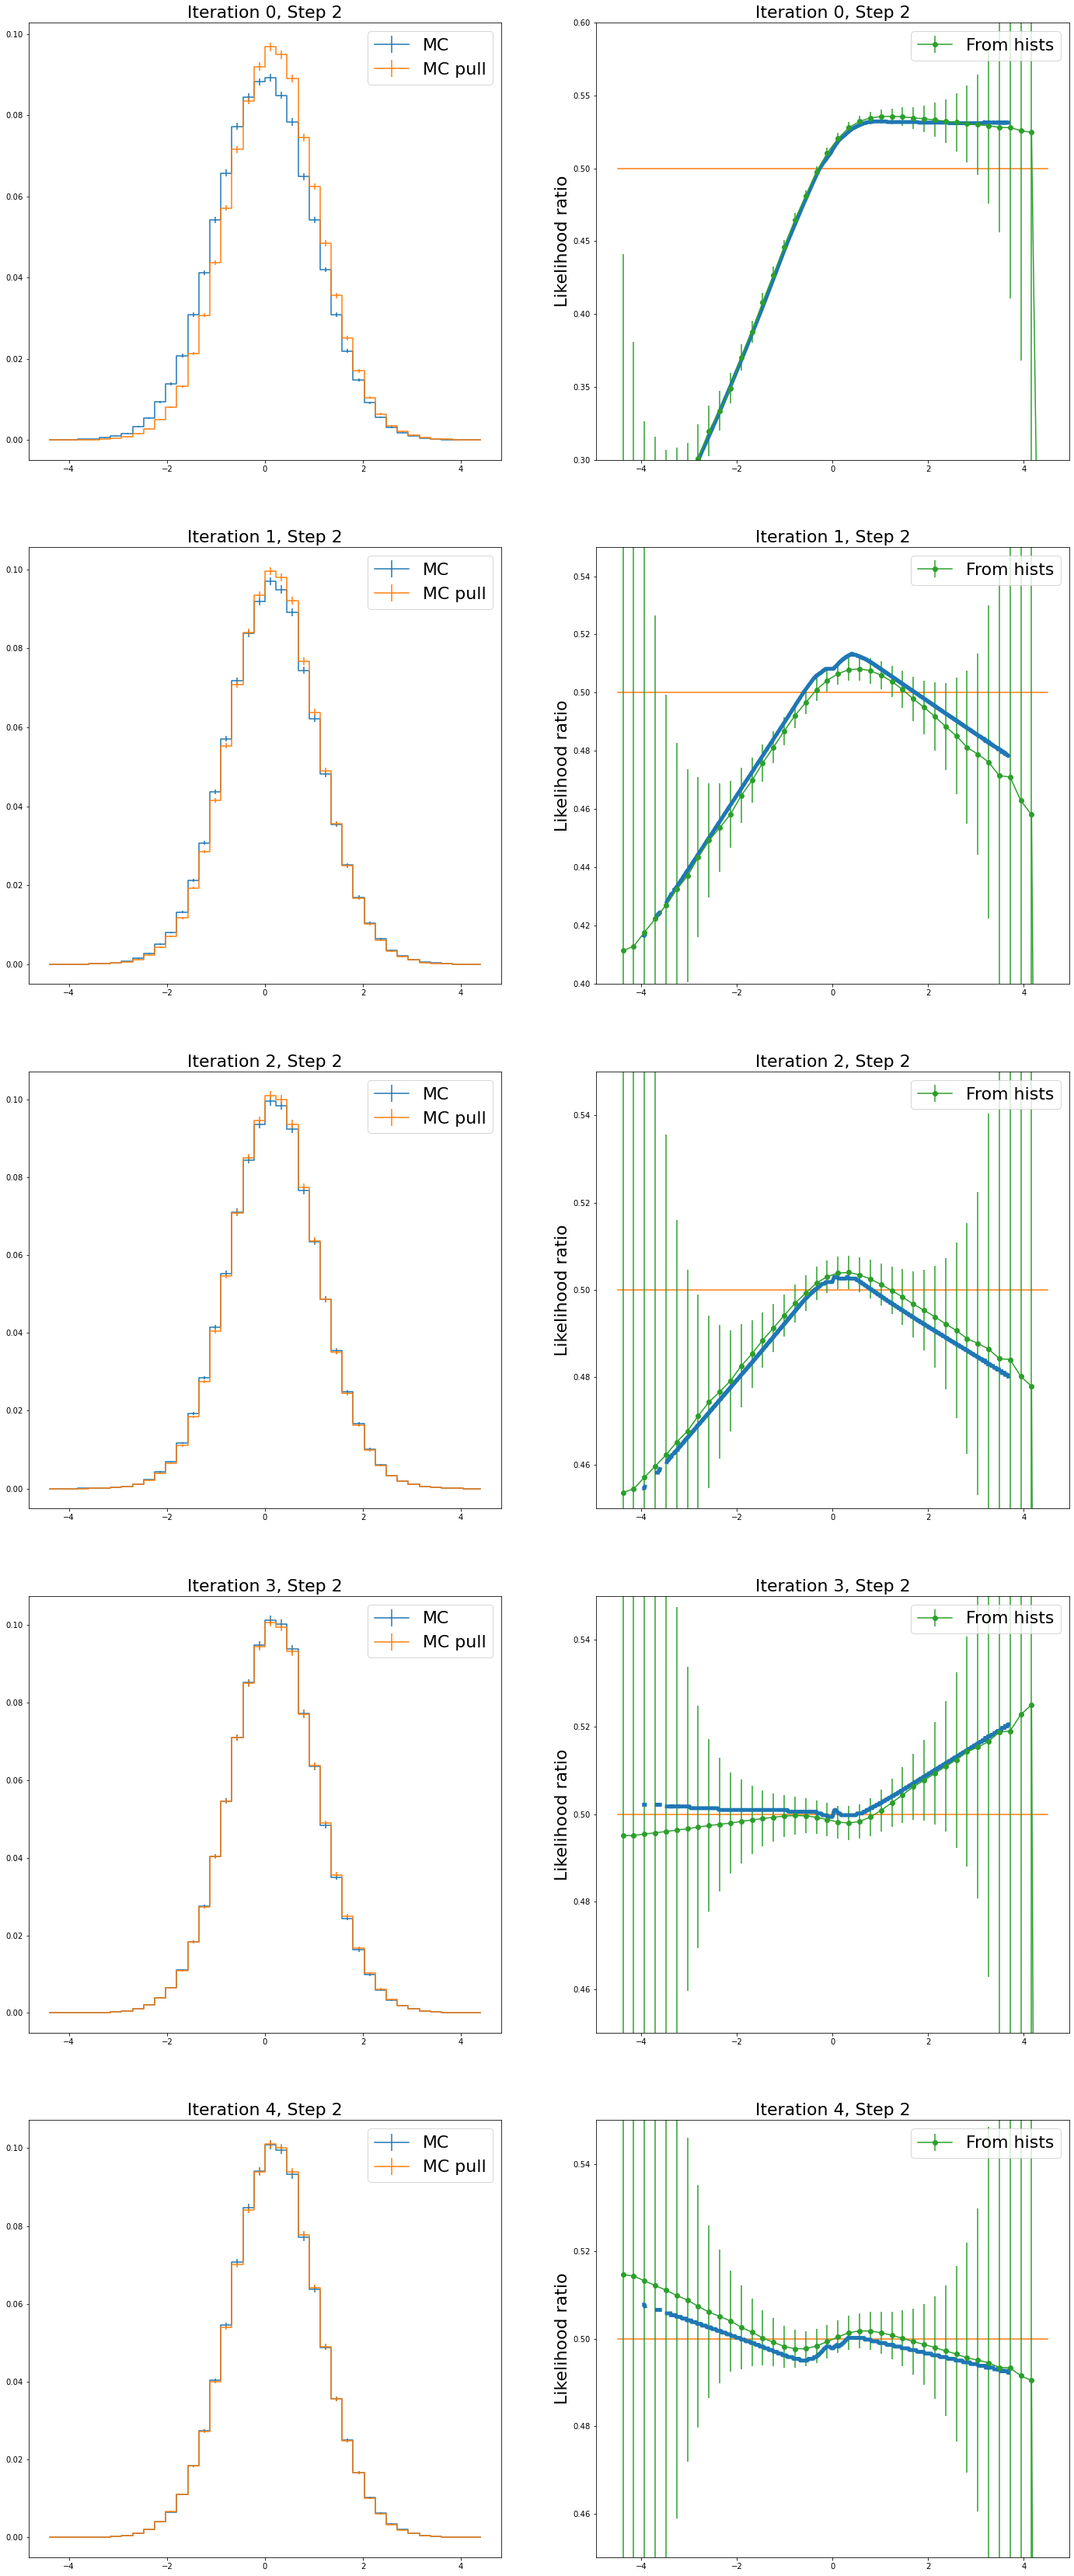

In [94]:

hxmin = -4.5
hxmax = 4.5


hnbins = 40



hbw = (hxmax-hxmin) / hnbins

xvals = np.zeros( hnbins )
for bi in range( hnbins ) :
    xvals[bi] = hxmin + (0.5 + bi)*hbw

nnbins = 1000

plotymin=[0.30, 0.40, 0.45, 0.45, 0.45]
plotymax=[0.60, 0.55, 0.55, 0.55, 0.55]

#plotymin=[0.30, 0.45, 0.49, 0.49, 0.49]
#plotymax=[0.60, 0.55, 0.51, 0.51, 0.51]





fig,ax = plt.subplots( of_niter, 2, figsize=(2*12,of_niter*12))


for ofi in range( of_niter ) :
    
    previous_push_weights = np.ones( len(train_pts[:,0]))
    if ofi > 0 :
        previous_push_weights = of_return_dict['push_weights'][ofi-1]
                
    pull_weights = previous_push_weights * of_return_dict['weights'][ofi,0,:]
    


    rd = prob_from_hists( train_pts[:,0], 
                             train_pts[:,0], 
                             previous_push_weights, 
                             pull_weights, 
                             hnbins, hxmin, hxmax )

    axi = ax[ofi][0]
    axi.errorbar( xvals, rd['hist_binsum_a'], rd['hist_err_a'], drawstyle='steps-mid', label='MC')
    axi.errorbar( xvals, rd['hist_binsum_b'], rd['hist_err_b'], drawstyle='steps-mid', label='MC pull')
    axi.legend( fontsize=22 )
    axi.set_title('Iteration %d, Step 2' % ofi, fontsize=22 )
        
    axi = ax[ofi][1]
    profile2d( axi, train_pts[:,0], of_prob[ofi,1,:], 
          hbins=[nnbins,nnbins], hrange=([xmin,xmax],[ymin,ymax]), drawhist=False, drawline=False ) 
    axi.plot([hxmin,hxmax],[0.5,0.5])
    axi.errorbar(xvals,rd['hist_ratio'],rd['hist_ratio_err'], marker='o', linestyle='-', label='From hists')
    axi.legend( fontsize=22 )
    axi.set_ylabel('Likelihood ratio', fontsize=22 )
    
    axi.set_ylim( plotymin[ofi], plotymax[ofi] )
    axi.set_title('Iteration %d, Step 2' % ofi, fontsize=22 )
        

        
        
plt.show

In [95]:
of_return_dict.keys()

dict_keys(['train-hist-step1-iter0', 'model_weights_step1_iter0', 'model_biases_step1_iter0', 'train-hist-step2-iter0', 'model_weights_step2_iter0', 'model_biases_step2_iter0', 'train-hist-step1-iter1', 'model_weights_step1_iter1', 'model_biases_step1_iter1', 'train-hist-step2-iter1', 'model_weights_step2_iter1', 'model_biases_step2_iter1', 'train-hist-step1-iter2', 'model_weights_step1_iter2', 'model_biases_step1_iter2', 'train-hist-step2-iter2', 'model_weights_step2_iter2', 'model_biases_step2_iter2', 'train-hist-step1-iter3', 'model_weights_step1_iter3', 'model_biases_step1_iter3', 'train-hist-step2-iter3', 'model_weights_step2_iter3', 'model_biases_step2_iter3', 'train-hist-step1-iter4', 'model_weights_step1_iter4', 'model_biases_step1_iter4', 'train-hist-step2-iter4', 'model_weights_step2_iter4', 'model_biases_step2_iter4', 'weights', 'ensemble_weights', 'push_weights', 'final_push_weights'])

In [96]:
s1_weights, s1_biases = model_step1.layers[0].get_weights()

<function matplotlib.pyplot.show(close=None, block=None)>

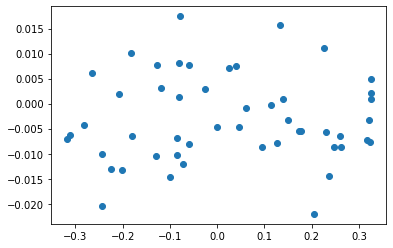

In [97]:
plt.scatter( s1_weights, s1_biases )
plt.show

In [98]:
s2_weights, s2_biases = model_step2.layers[0].get_weights()

<function matplotlib.pyplot.show(close=None, block=None)>

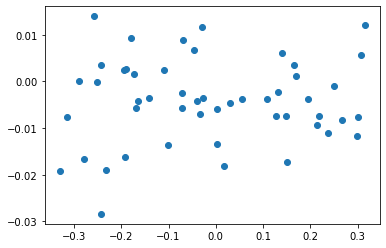

In [99]:
plt.scatter( s2_weights, s2_biases )
plt.show

In [100]:
w,b = model_step1.layers[2].get_weights()

In [101]:
w.shape

(50, 50)

In [102]:
s1_weights.shape

(1, 50)

<function matplotlib.pyplot.show(close=None, block=None)>

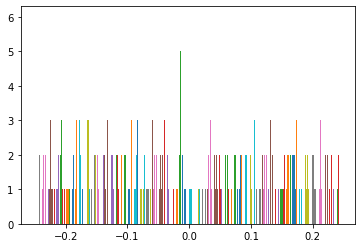

In [103]:
plt.hist( w, bins=50)
plt.show

In [104]:
of_return_dict['model_weights_step1_iter0'][0].shape

(50,)

<function matplotlib.pyplot.show(close=None, block=None)>

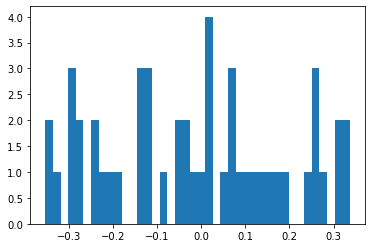

In [105]:
plt.hist(  of_return_dict['model_weights_step1_iter0'][0], bins=40  )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

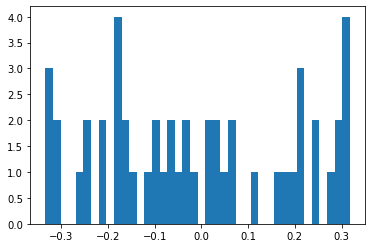

In [106]:
plt.hist(  of_return_dict['model_weights_step1_iter1'][0], bins=40  )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

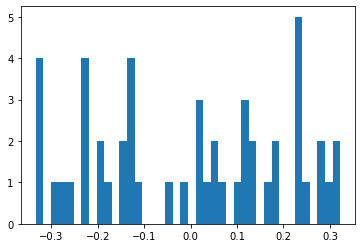

In [107]:
plt.hist(  of_return_dict['model_weights_step1_iter2'][0], bins=40  )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

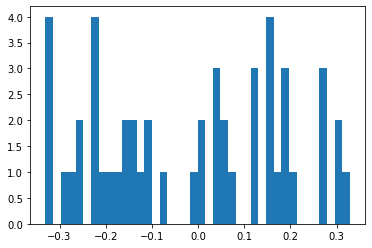

In [108]:
plt.hist(  of_return_dict['model_weights_step1_iter3'][0], bins=40  )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

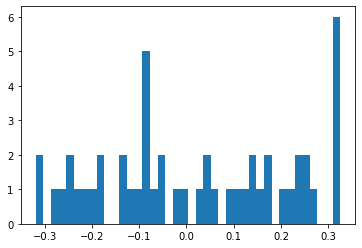

In [109]:
plt.hist(  of_return_dict['model_weights_step1_iter4'][0], bins=40  )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

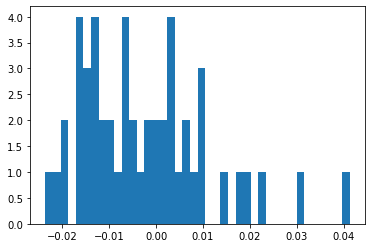

In [110]:
plt.hist(  of_return_dict['model_biases_step1_iter0'], bins=40  )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

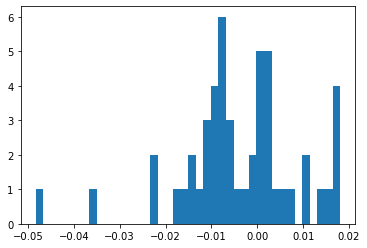

In [111]:
plt.hist(  of_return_dict['model_biases_step1_iter1'], bins=40  )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

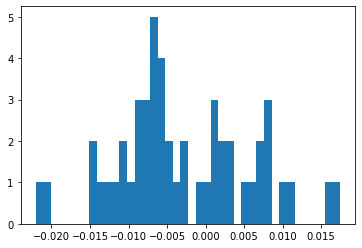

In [112]:
plt.hist(  of_return_dict['model_biases_step1_iter4'], bins=40  )
plt.show

In [113]:
model_step1

<Sequential name=sequential, built=True>

In [114]:
model_step1.layers

[<Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>,
 <Dropout name=dropout_1, built=True>,
 <Dense name=dense_2, built=True>,
 <Dropout name=dropout_2, built=True>,
 <Dense name=dense_3, built=True>]

In [115]:
model_step1.layers[0].get_weights()

[array([[-1.28479108e-01,  2.04865143e-01,  3.94587778e-02,
          9.40323547e-02,  4.74453918e-05, -1.82140574e-01,
          1.48998678e-01,  2.36053437e-01, -7.16873035e-02,
          2.60117829e-01,  4.60752100e-02,  1.73566028e-01,
          2.56303065e-02, -2.82171518e-01, -2.44038239e-01,
         -1.79966941e-01, -9.98830870e-02,  2.47033983e-01,
         -2.01389223e-01,  1.26051575e-01, -2.25502864e-01,
          3.25301081e-01, -3.11110258e-01,  2.30080470e-01,
          3.23469639e-01,  3.25376868e-01, -1.27319589e-01,
          6.04466870e-02,  3.21875095e-01, -2.63821989e-01,
         -2.43021011e-01, -8.02436024e-02,  1.40304804e-01,
         -6.03682362e-02,  1.76534876e-01, -3.18669617e-01,
          3.24862272e-01,  1.32745951e-01, -8.51580575e-02,
         -1.19785510e-01, -7.93578029e-02,  2.27006689e-01,
          3.16228628e-01, -8.11080113e-02,  1.14107884e-01,
          2.63059288e-01, -5.95544167e-02, -2.08073661e-01,
         -2.64007580e-02, -8.55540782e-0

In [116]:
for ni in range( units_per_layer ) :
    print(' node %3d :' % ni, end = '')
    for ii in range( of_niter ) :
        print( ' %7.4f ' % of_return_dict['model_weights_step1_iter%d' % ii][0,ni], end='' )
    print(' | ', end='')
    for ii in range( of_niter ) :
        print( ' %7.4f ' % of_return_dict['model_biases_step1_iter%d' % ii][ni], end='' )
    print()


 node   0 :  0.2806  -0.1819   0.0328  -0.3148  -0.1285  |  -0.0094   0.0017   0.0004  -0.0079  -0.0105 
 node   1 :  0.2587   0.1941  -0.2206   0.1950   0.2049  |   0.0039   0.0165  -0.0060  -0.0041  -0.0220 
 node   2 :  0.0861  -0.1801   0.0462   0.0337   0.0395  |  -0.0110   0.0016   0.0034   0.0066   0.0075 
 node   3 :  0.1551  -0.2060  -0.1349   0.1295   0.0940  |   0.0151  -0.0219   0.0030  -0.0052  -0.0087 
 node   4 :  0.0647  -0.2425   0.2937  -0.3198   0.0000  |   0.0194  -0.0121   0.0059  -0.0051  -0.0047 
 node   5 : -0.0295  -0.0654   0.1270  -0.2878  -0.1821  |   0.0413  -0.0071  -0.0080  -0.0139   0.0101 
 node   6 :  0.0518   0.2185  -0.0185   0.0802   0.1490  |  -0.0008  -0.0153  -0.0046  -0.0028  -0.0032 
 node   7 :  0.2641   0.3016  -0.1928  -0.2176   0.2361  |   0.0300  -0.0222  -0.0048  -0.0095  -0.0144 
 node   8 : -0.0518   0.3000   0.2297   0.1679  -0.0717  |   0.0001  -0.0083   0.0013  -0.0016  -0.0121 
 node   9 : -0.2889   0.0285  -0.1860   0.1502   0.2601

# Bootstrap / Toy MC below here

In [117]:
verbose = False



import gc

In [118]:
try:
    os.mkdir( "%s/bootstrap-nn-models" % output_dir )
except :
    print('problem creating bootstrap-nn-models dir')


In [119]:
%%time

rng = np.random.default_rng()

for bi in range(0,n_boot_samples) :
    
    this_random_seed = random_seed*10000+bi
    
    np.random.seed( this_random_seed )
    keras.utils.set_random_seed( this_random_seed )

    
    if do_bootstrap :
        print("\n Creating bootstrap sample %3d,  seed %d" % (bi, this_random_seed) )
        boot_true_det_pts = rng.choice( true_det_pts, size=len(true_det_pts) )
        
    else :
        this_ngen_true = ngen_true
        if use_poisson_fluctuations_around_ngen_true : this_ngen_true = np.random.poisson( ngen_true )
        print("\n Creating toy sample %3d,  this_ngen_true = %d, seed %d" % (bi, this_ngen_true, this_random_seed) )
        boot_true_pts = np.random.multivariate_normal(true_mu, true_cov, size=this_ngen_true)
        boot_true_det_pts = np.random.normal( boot_true_pts, resolution )
        
    modeldir = "%s/bootstrap-nn-models/bs-%03d" % (output_dir, bi) 
    
    try:
        os.mkdir( modeldir )
    except :
        print('\n\n *** probelm creating model output directory : %s' % modeldir )

        









    
    
    
    
    ##-----------  Begin OmniFold
    
    
        
    #boot_of_return_dict = of.omnifold9b( 
    #    train_both, boot_true_det_pts, of_niter, model_step1, model_step2, verbose, 
    #    batch_size_setval, epochs_setval, True, modeldir )

    theta0 = train_both
    theta_unknown_S = boot_true_det_pts  #--- fixed bug here.
    iterations = of_niter
    verbose = False

    
    #======= begin new =================================================

    ensemble_weights = np.empty(shape=(n_models_to_ensemble, iterations, 2, len(theta0)))
    weights = np.empty(shape=(iterations, 2, len(theta0)))
    # shape = (iteration, step, event)
    push_weights_for_output = np.empty(shape=(iterations, len(theta0)))

    theta0_G = theta0[:,0]
    theta0_S = theta0[:,1]

    labels0 = np.zeros(len(theta0))
    labels_unknown = np.ones(len(theta_unknown_S))
    labels_unknown_step2 = np.ones(len(theta0_G))

    pretrain_xvals_1 = np.concatenate((theta0_S, theta0_S))
    pretrain_yvals_1 = np.concatenate( (np.ones(len(theta0_S)), np.zeros(len(theta0_S))) )
    xvals_1 = np.concatenate((theta0_S, theta_unknown_S))
    yvals_1 = np.concatenate((labels0, labels_unknown))

    pretrain_xvals_2 = np.concatenate((theta0_G, theta0_G))
    pretrain_yvals_2 = np.concatenate( (np.ones(len(theta0_G)), np.zeros(len(theta0_G))) )
    xvals_2 = np.concatenate((theta0_G, theta0_G))
    yvals_2 = np.concatenate((labels0, labels_unknown_step2))

    if verbose :
        print("\n\n")
        print("  ======== omnifold9c\n\n")
        print("  shape of theta0_S : %s" % str(np.shape(theta0_S)) ) ;
        print("  shape of theta_unknown_S : %s" % str(np.shape(theta_unknown_S)) ) ;
        print("  shape of xvals_1 :  %s" % str(np.shape( xvals_1 )) ) ;
        print("\n\n")
        print("  shape of labels0 : %s" % str(np.shape(labels0)) ) ;
        print("  shape of labels_unknown : %s" % str(np.shape(labels_unknown)) ) ;
        print("  shape of yvals_1 :  %s" % str(np.shape( yvals_1 )) ) ;
        print("\n\n")
        print("  shape of theta0_G : %s" % str(np.shape(theta0_G)) ) ;
        print("  shape of xvals_2 :  %s" % str(np.shape( xvals_2 )) ) ;
        print("  shape of yvals_2 :  %s" % str(np.shape( yvals_2 )) ) ;
        print("\n batch size setval  %d" % batch_size_setval )
        print(" epochs setval  %d" % epochs_setval )
        print("\n\n")

    # initial iterative weights are ones
    weights_pull = np.ones(len(theta0_S))
    weights_push = np.ones(len(theta0_S))


    # owen: rescale the MC weights to balance the two categories for step 1 in first iteration.
    mc_weight_sf = (1.*len(theta_unknown_S))/(1.*len(theta0_S))


    return_dict = {}    

    for i in range(iterations):

        if (verbose>0):
            print("\nITERATION: {}\n".format(i + 1))
            pass

        # STEP 1: classify Sim. (which is reweighted by weights_push) to Data
        # weights reweighted Sim. --> Data

        if (verbose>0):
            print("   -- ITERATION %d  STEP 1\n" % (i+1) )
            pass

        print(" weights_push at the beginning")
        print( weights_push )







     # owen: put the scaling here so that weights_push keeps its meaning (order 1).
        weights_1 = np.concatenate((mc_weight_sf * weights_push, np.ones(len(theta_unknown_S))))

        X_train_1, X_test_1, Y_train_1, Y_test_1, w_train_1, w_test_1 = train_test_split(xvals_1, yvals_1, weights_1)

        # zip ("hide") the weights with the labels
        Y_train_1 = np.stack((Y_train_1, w_train_1), axis=1)
        Y_test_1 = np.stack((Y_test_1, w_test_1), axis=1)


        for ei in range( n_models_to_ensemble ) :

            if verbose>0 : print(' Iter %d, step 1, ensemble index %d' % (i, ei) )

            reset_model_weights( model_step1 )    

            if i > -1 :

                    pretrain_weights_1 = np.concatenate( (np.ones(len(theta0_S)), np.ones(len(theta0_S))) )

                    pt_X_train_1, pt_X_test_1, pt_Y_train_1, pt_Y_test_1, pt_w_train_1, pt_w_test_1 = train_test_split(pretrain_xvals_1, pretrain_yvals_1, pretrain_weights_1)

                    pt_Y_train_1 = np.stack((pt_Y_train_1, pt_w_train_1), axis=1)
                    pt_Y_test_1 = np.stack((pt_Y_test_1, pt_w_test_1), axis=1)

                    if verbose>0 :
                            print("             running pre-training, distinguish from self.")

                    model_step1.fit( pt_X_train_1, pt_Y_train_1, epochs=5, batch_size=batch_size_setval, verbose=verbose )

                    if verbose>0 :
                            print("             done pretraining.")

            this_epochs = epochs_setval
            if i == 0 : this_epochs = this_epochs*2


            train_history_step1 = model_step1.fit(X_train_1,
                      Y_train_1,
                      epochs=this_epochs,
                      batch_size=batch_size_setval,
                      validation_data=(X_test_1, Y_test_1),
                      verbose=verbose )

            ensemble_weights[ei, i, 0, :] = reweight(theta0_S,model_step1)





        #step1_output_weights = reweight(theta0_S,model_step1)

        step1_output_weights = np.average( ensemble_weights[:,i,0,:], axis=0 )




        weights_pull = weights_push * step1_output_weights

        weights[i, :1, :] = step1_output_weights

        return_dict["train-hist-step1-iter%d" % i] = train_history_step1

        return_dict['model_weights_step1_iter%d' % i] = np.copy( model_step1.layers[0].get_weights()[0] )

        return_dict['model_biases_step1_iter%d' % i] = np.copy( model_step1.layers[0].get_weights()[1] )


        # STEP 2: classify Gen. to reweighted Gen. (which is reweighted by weights_pull)
        # weights Gen. --> reweighted Gen.

        if (verbose>0):
            print("\n   -- ITERATION %d  STEP 2\n" % (i+1) )
            pass


        for ei in range( n_models_to_ensemble ) :

            if verbose>0 : print(' Iter %d, step 2, ensemble index %d' % (i, ei) )

            reset_model_weights( model_step2 )

            # ones for Gen. (not MC weights), actual weights for (reweighted) Gen.
            weights_2 = np.concatenate((   weights_push  , weights_pull))

            X_train_2, X_test_2, Y_train_2, Y_test_2, w_train_2, w_test_2 = train_test_split(xvals_2, yvals_2, weights_2)

            # zip ("hide") the weights with the labels
            Y_train_2 = np.stack((Y_train_2, w_train_2), axis=1)
            Y_test_2 = np.stack((Y_test_2, w_test_2), axis=1)

            if i > -1 :

                    pretrain_weights_2 = np.concatenate( (np.ones(len(theta0_G)), np.ones(len(theta0_G))) )

                    pt_X_train_2, pt_X_test_2, pt_Y_train_2, pt_Y_test_2, pt_w_train_2, pt_w_test_2 = train_test_split(pretrain_xvals_2, pretrain_yvals_2, pretrain_weights_2)

                    pt_Y_train_2 = np.stack((pt_Y_train_2, pt_w_train_2), axis=1)
                    pt_Y_test_2 = np.stack((pt_Y_test_2, pt_w_test_2), axis=1)

                    if verbose>0 :
                            print("             running pre-training, distinguish from self.")

                    model_step2.fit( pt_X_train_2, pt_Y_train_2, epochs=5, batch_size=batch_size_setval, verbose=verbose )

                    if verbose>0 :
                            print("             done pretraining.")


            train_history_step2 = model_step2.fit(X_train_2,
                      Y_train_2,
                      epochs=this_epochs,
                      batch_size=batch_size_setval,
                      validation_data=(X_test_2, Y_test_2),
                      verbose=verbose )

            return_dict["train-hist-step2-iter%d" % i] = train_history_step2

            return_dict['model_weights_step2_iter%d' % i] = np.copy( model_step2.layers[0].get_weights()[0] )

            return_dict['model_biases_step2_iter%d' % i] = np.copy( model_step2.layers[0].get_weights()[1] )


            ensemble_weights[ei, i, 1, :] = reweight(theta0_G,model_step2)






        #step2_output_weights = reweight(theta0_G,model_step2)

        step2_output_weights = np.average( ensemble_weights[:,i,1,:], axis=0 )


        weights_push = step2_output_weights * weights_push

        push_weights_for_output[i] = weights_push

        weights[i, 1:2, :] = step2_output_weights

        if save_step2_model :
            model_output_dir = "%s/of-step2-iter%02d-model" % (output_dir, i)
            print("\n +++ Saving step 2, iteration %d model in %s" % (i, model_output_dir) )
            model_step2.save( "%s.keras" % model_output_dir )

    return_dict["weights"] = weights

    return_dict["ensemble_weights"] = ensemble_weights

    return_dict["push_weights"] = push_weights_for_output

    return_dict["final_push_weights"] = weights_push

    boot_of_return_dict = return_dict
    
    #====== end new ==================================================
    
    
    

    #-------------  End OmniFold

    mc_weight_sf = (1.*len(boot_true_det_pts))/(1.*len(train_both))



    boot_final_push_weights = boot_of_return_dict["final_push_weights"]
    boot_final_push_weights_scaled = boot_final_push_weights
    boot_final_push_weights_scaled = mc_weight_sf * boot_final_push_weights
    
    print("\n\n bootstrap %d final push weights scaled:" % bi)
    print( boot_final_push_weights_scaled )

     
    with open( '%s/bootstrap-weights-%03d.npy' % ( output_dir, bi ), 'wb' ) as f :
        np.save( f, boot_final_push_weights_scaled )

    with open( '%s/bootstrap-points-%03d.npy' % ( output_dir, bi ), 'wb' ) as f :
        np.save( f, boot_true_det_pts )
        
        
    del boot_final_push_weights_scaled
    del boot_of_return_dict
    gc.collect()
    
    


 Creating toy sample   0,  this_ngen_true = 10013, seed 10000
 weights_push at the beginning
[1. 1. 1. ... 1. 1. 1.]
Resetting weights for model <Sequential name=sequential, built=True>


2025-02-10 11:39:37.408573: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_495', 92 bytes spill stores, 92 bytes spill loads

2025-02-10 11:39:37.688073: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_495', 208 bytes spill stores, 208 bytes spill loads



10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 610us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step
Resetting weights for model <Sequential name=sequential_1, built=True>


2025-02-10 11:42:19.533243: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_495', 180 bytes spill stores, 180 bytes spill loads

2025-02-10 11:42:19.701665: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_495', 208 bytes spill stores, 208 bytes spill loads



10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 611us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step
Resetting weights for model <Sequential name=sequential_1, built=True>


...

Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 660us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 608us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step
Re

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 655us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 627us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 636us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step
Resetting weights for model <Sequential name=sequential_1, built=True>


2025-02-10 16:06:02.840005: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_495', 192 bytes spill stores, 192 bytes spill loads

2025-02-10 16:06:03.153625: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_495', 208 bytes spill stores, 208 bytes spill loads



10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 608us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 655us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step
Resetting weights for model <Sequential name=sequential_1, built=True>


Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step
Resetting weights for model <Sequential name=sequential, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step
Resetting weights for model <Sequential name=sequential_1, built=True>
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step
Re

In [120]:
print('\n\n Done.\n\n')



 Done.


